In [6]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정
def set_matplotlib_font():
    system = platform.system()
    if system == "Windows":
        plt.rc('font', family='Malgun Gothic')
    elif system == "Darwin":  # macOS
        plt.rc('font', family='AppleGothic')
    elif system == "Linux":
        plt.rc('font', family='NanumGothic')
    else:
        print("Unknown system. Please set font manually.")
    plt.rcParams['axes.unicode_minus'] = False
set_matplotlib_font()

# 전체 수요예측

## ARIMA 모델

Train shape: (157, 2), Test shape: (52, 2)

✅ SARIMA Test MSE: 113517470.77, RMSE: 10654.46


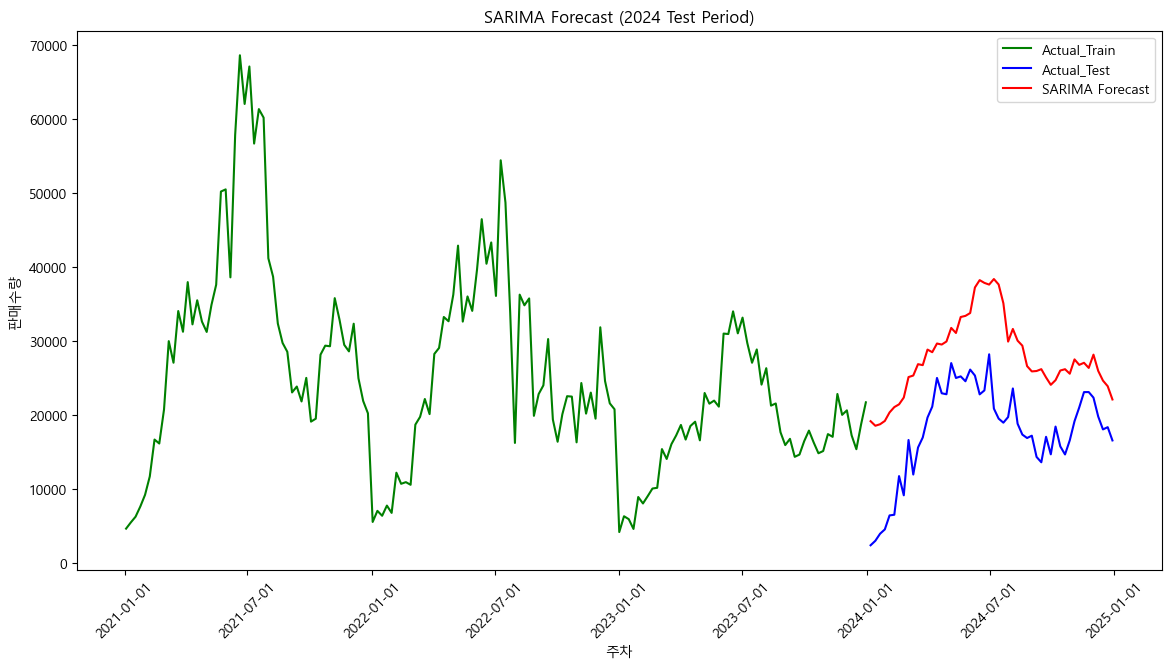


✅ 2024년 실제 총 판매량: 929393 장
✅ 2024년 SARIMA 예측 총 판매량: 1447833 장


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# 데이터 불러오기 및 전처리
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df['y'] = df['판매수량'].clip(lower=0)
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# SARIMA 모델 학습 및 예측
sarima_model = sm.tsa.SARIMAX(
    train_data['y'], 
    order=(1,1,1), 
    seasonal_order=(1,1,1,52),  # 주간 데이터라 seasonality 52로 설정
    enforce_stationarity=False, 
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()

# 2024년 test 구간 길이만큼 예측
forecast_length = len(test_data)
sarima_forecast = sarima_result.get_forecast(steps=forecast_length)
forecast_mean = sarima_forecast.predicted_mean
forecast_ci = sarima_forecast.conf_int()

# 평가 지표 계산
mse = mean_squared_error(test_data['y'], forecast_mean)
rmse = np.sqrt(mse)
print(f"\nSARIMA Test MSE: {mse:.2f}, RMSE: {rmse:.2f}")

# 시각화 (Prophet과 동일 포맷)
plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(test_data['ds'], forecast_mean, label='SARIMA Forecast', color='red')

plt.title('SARIMA Forecast (2024 Test Period)')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = forecast_mean.sum()
print(f"\n2024년 실제 총 판매량: {actual_sales_2024:.0f} 장")
print(f"2024년 SARIMA 예측 총 판매량: {forecast_sales_2024:.0f} 장")


## AUTO-ARIMA

Train shape: (157, 2), Test shape: (52, 2)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=3153.379, Time=3.43 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=3160.611, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=3154.952, Time=0.27 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=3154.564, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=3158.666, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[52] intercept   : AIC=3151.389, Time=2.45 sec
 ARIMA(2,1,2)(0,0,0)[52] intercept   : AIC=3153.091, Time=0.50 sec
 ARIMA(2,1,2)(0,0,2)[52] intercept   : AIC=3153.383, Time=7.30 sec
 ARIMA(2,1,2)(1,0,0)[52] intercept   : AIC=3151.382, Time=1.94 sec
 ARIMA(2,1,2)(2,0,0)[52] intercept   : AIC=3153.379, Time=9.84 sec
 ARIMA(2,1,2)(2,0,1)[52] intercept   : AIC=3155.379, Time=9.92 sec
 ARIMA(1,1,2)(1,0,0)[52] intercept   : AIC=3157.897, Time=0.91 sec
 ARIMA(2,1,1)(1,0,0)[52] intercept   : AIC=3158.283, Time=1.03 sec
 ARIMA(3,1,2)(1,0,0)[52] intercept   : AIC=

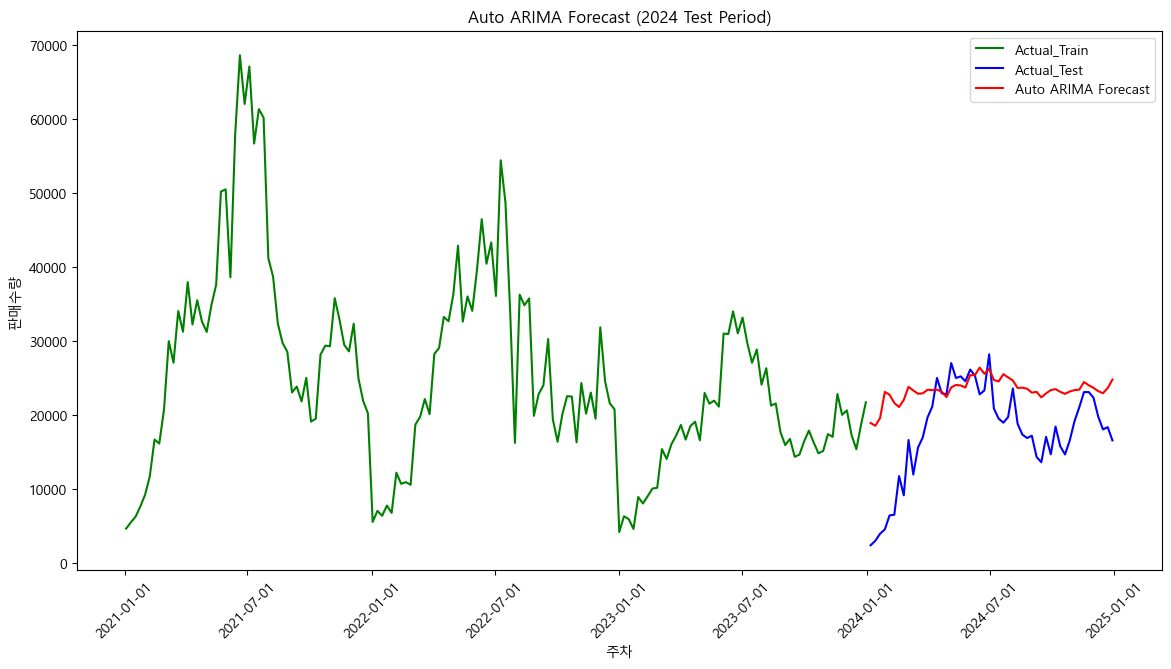


✅ 2024년 실제 총 판매량: 929393 장
✅ 2024년 Auto ARIMA 예측 총 판매량: 1218909 장


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')

# 데이터 불러오기 및 전처리
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df['y'] = df['판매수량'].clip(lower=0)
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# Auto ARIMA 파라미터 최적화
auto_model = pm.auto_arima(
    train_data['y'],
    seasonal=True,
    m=52,  # 주차 단위이므로 seasonality = 52
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(f"\nAuto ARIMA Best Model: {auto_model.summary()}")

# 예측
forecast_length = len(test_data)
auto_forecast = auto_model.predict(n_periods=forecast_length)

# 평가 지표 계산
mse = mean_squared_error(test_data['y'], auto_forecast)
rmse = np.sqrt(mse)
print(f"\nAuto ARIMA Test MSE: {mse:.2f}, RMSE: {rmse:.2f}")

# 시각화 (Prophet과 동일 포맷)
plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(test_data['ds'], auto_forecast, label='Auto ARIMA Forecast', color='red')

plt.title('Auto ARIMA Forecast (2024 Test Period)')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = auto_forecast.sum()
print(f"\n2024년 실제 총 판매량: {actual_sales_2024:.0f} 장")
print(f"2024년 Auto ARIMA 예측 총 판매량: {forecast_sales_2024:.0f} 장")


## Prophet

## 최적 하이퍼파라미터 선정, 21~23년 데이터로 학습 후 24년 데이터로 평가

Train shape: (157, 2), Test shape: (52, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.9, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.9, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.9, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.9, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=1, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=1, SPS=5...
🔹 Testing Seasonality=multiplic

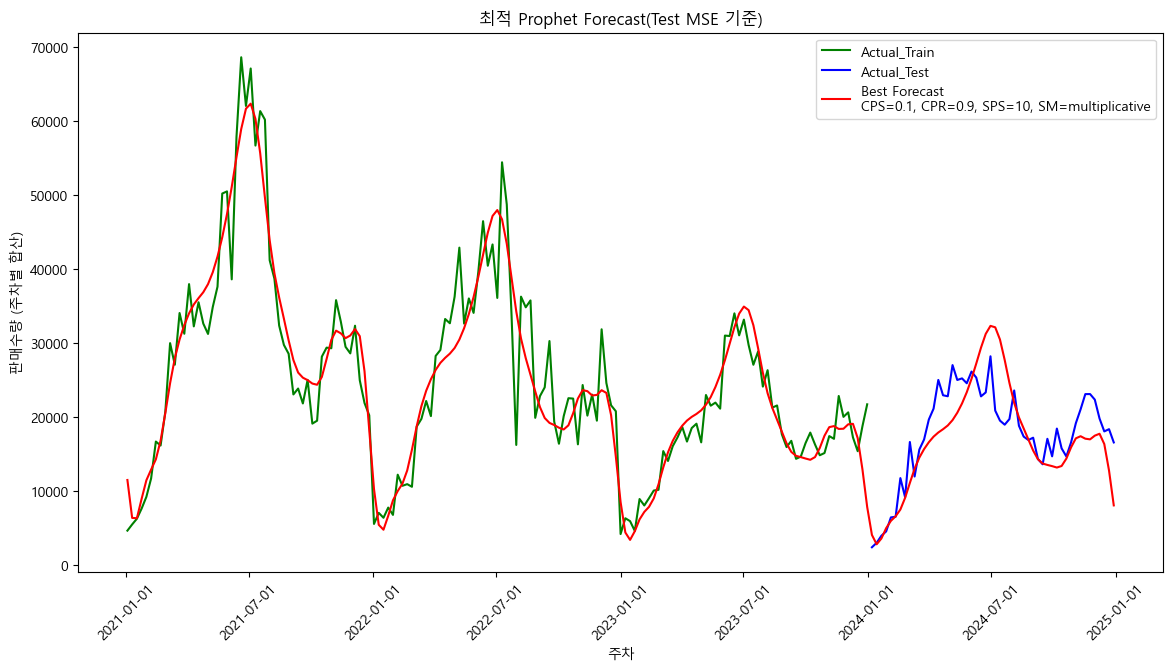


🔹 2024년 실제 총 판매량: 929393 장
🔹 2024년 Prophet 예측 총 판매량: 880668 장


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 전처리
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.05, 0.1, 0.2] #기본값 0.05
changepoint_range_list = [0.7, 0.8, 0.9, 1] #기본값 0.8
seasonality_prior_scale_list = [1, 5, 10, 50] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량: {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량: {forecast_sales_2024:.0f} 장")


## 25년 예측


2024년 총 판매량: 929114 장
2024년 총 입고수량: 1381439 장
최종 학습 데이터 Shape: (209, 2)

🔹 2025년 총 예상 판매량 : 910493 장
🔹 2025년 입고 계획량 (예비 20% 포함): 1092592 장


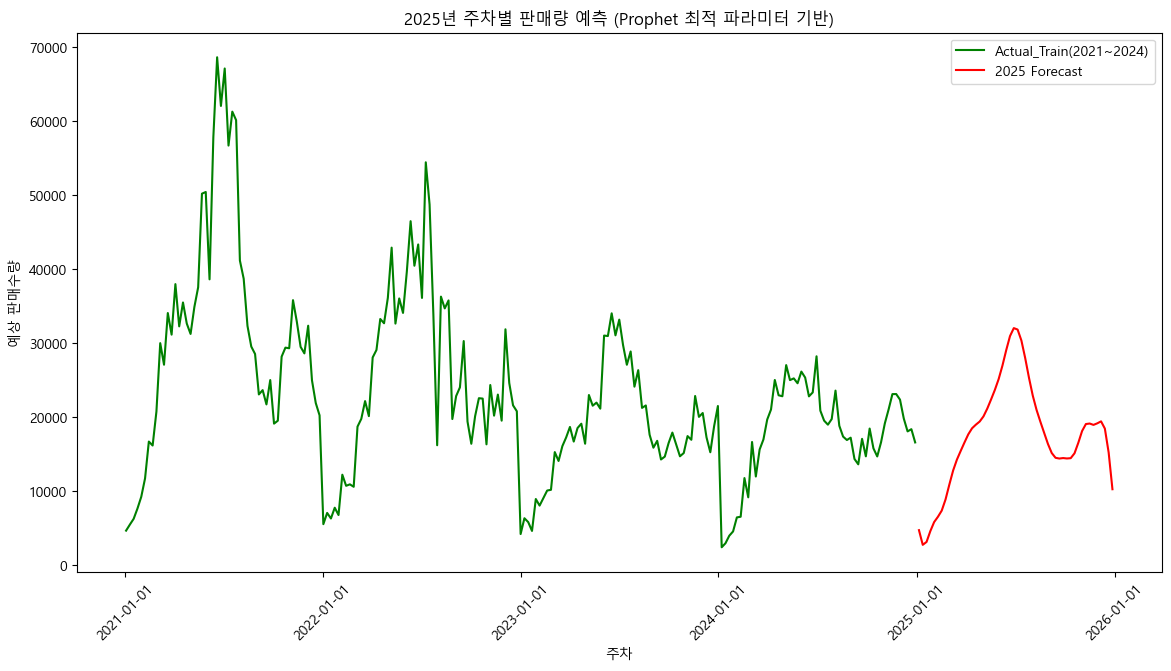

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])

# 2024년 총 판매량 + 총 입고수량 계산용
df_2024 = df[df['주차'].dt.year == 2024].copy()

# 총 판매량
total_sales_2024 = df_2024['판매수량'].sum()

# 총 입고수량(카테고리별 마지막 주차 '총입고수량' 합산)
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape: {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.1,
    changepoint_range=0.9,
    seasonality_prior_scale=10,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 에측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast', color='red')
plt.title('2025년 주차별 판매량 예측 (Prophet 최적 파라미터 기반)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

In [88]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])

# 2024년 데이터 필터링 + 복종 필터링
target_categories = ["가죽&FUR", "니트 셔츠", "데님", "사파리", "수트", 
                     "스웨터", "우븐 셔츠", "자켓", "점퍼", "조끼", "코트", "팬츠"]

df_2024 = df[(df['주차'].dt.year == 2024) & (df['복종'].isin(target_categories))].copy()

# 복종별 판매수량 합산
category_sales = df_2024.groupby('복종')['판매수량'].sum().reset_index()

# 전체 판매량
total_sales_2024 = category_sales['판매수량'].sum()

# 복종별 판매비중 계산
category_sales['판매비중'] = category_sales['판매수량'] / total_sales_2024

print("\n2024년 복종별 판매 비중 (%)")
print(category_sales[['복종', '판매비중']].sort_values(by='판매비중', ascending=False))

# 전체 입고 계획량 (예측값)
total_inbound_plan = 1092592  # <-- 여기에 Prophet 예측으로 나온 총입고량 입력

# 복종별 입고 계획 수량 계산
category_sales['입고계획수량'] = (category_sales['판매비중'] * total_inbound_plan).astype(int)

print("\n2025년 복종별 입고계획수량")
category_sales[['복종', '입고계획수량']].sort_values(by='입고계획수량', ascending=False)



2024년 복종별 판매 비중 (%)
       복종      판매비중
5   우븐 셔츠  0.214994
3      수트  0.184721
10     팬츠  0.165905
4     스웨터  0.158579
0   니트 셔츠  0.153008
7      점퍼  0.032450
6      자켓  0.029212
9      코트  0.021431
1      데님  0.018133
2     사파리  0.017920
8      조끼  0.003645

2025년 복종별 입고계획수량


,복종,입고계획수량
5,우븐 셔츠,234900
3,수트,201824
10,팬츠,181266
4,스웨터,173262
0,니트 셔츠,167175
7,점퍼,35454
6,자켓,31916
9,코트,23415
1,데님,19812
2,사파리,19579



✅ Bass Model Parameters → p: 0.0054, q: 0.1013, m: 940169

📌 도입기 끝/성장기 시작 (T1): 2025-03-23 (판매량 13735 장)
📌 성장기 끝/성숙기 시작 (T*): 2025-07-13 (판매량 26405 장)
📌 성숙기 끝/쇠퇴기 시작 (T2): 2025-08-31 (판매량 23039 장)

✅ PLC 구간별 누적 판매량 (장):
도입기: 95323 장
성장기: 336635 장
성숙기: 178302 장
쇠퇴기: 262355 장


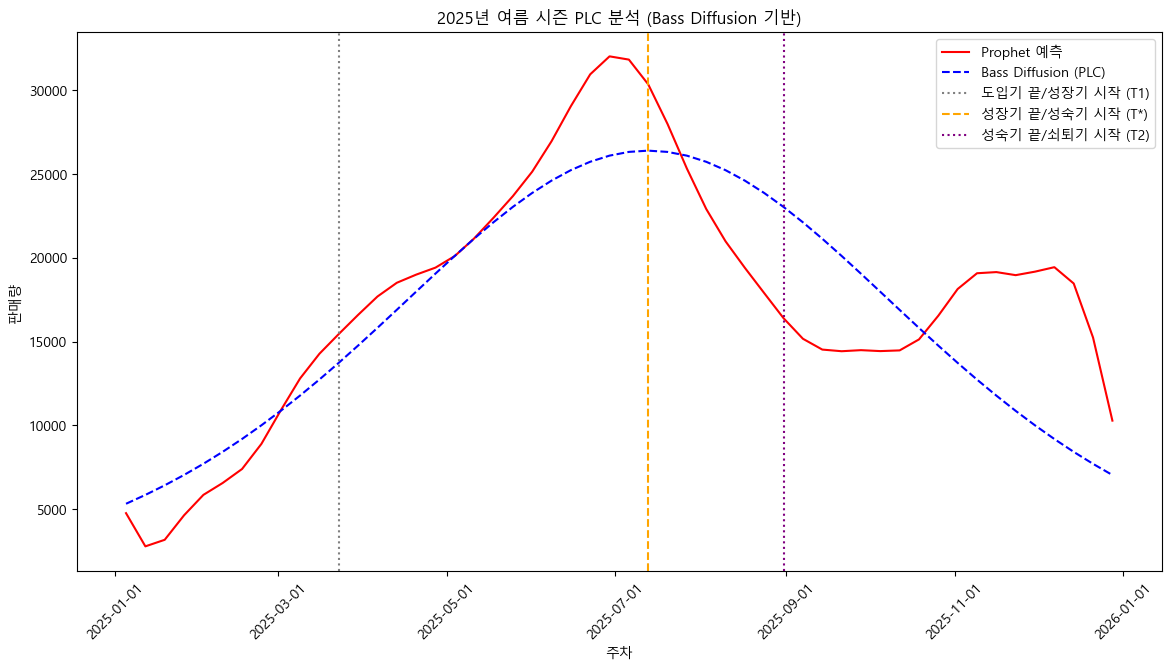

In [ ]:
from scipy.optimize import curve_fit

# Prophet 예측 판매량으로 Bass 모델 fitting
sales_array = forecast_2025['yhat'].values
time = np.arange(1, len(sales_array) + 1)

# Bass 누적 모델 정의 (cumulative로 curve_fit)
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

cumulative_sales = np.cumsum(sales_array)
params, _ = curve_fit(bass_cumulative, time, cumulative_sales, bounds=(0, [1, 1, 1e7]))
p, q, m_val = params

print(f"\nBass Model Parameters → p: {p:.4f}, q: {q:.4f}, m: {m_val:.0f}")

# Bass 곡선 생성 (순판매량으로 변환)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
T_star_week = forecast_2025['ds'].iloc[T_star_idx]
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T1_week = forecast_2025['ds'].iloc[T1_idx]

total_bass_sales = np.sum(bass_curve)
target_cumulative = total_bass_sales * 0.7
cumulative_bass = np.cumsum(bass_curve)

# 누적 판매량이 70% 넘는 지점 찾기
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]
T2_week = forecast_2025['ds'].iloc[T2_idx]

print(f"\n📌 도입기 끝/성장기 시작 (T1): {T1_week.date()} (판매량 {bass_curve[T1_idx]:.0f} 장)")
print(f"📌 성장기 끝/성숙기 시작 (T*): {T_star_week.date()} (판매량 {bass_curve[T_star_idx]:.0f} 장)")
print(f"📌 성숙기 끝/쇠퇴기 시작 (T2): {T2_week.date()} (판매량 {bass_curve[T2_idx]:.0f} 장)")

# PLC 구간별 누적 판매량 계산
intro_sales = np.sum(bass_curve[:T1_idx])
growth_sales = np.sum(bass_curve[T1_idx:T_star_idx])
mature_sales = np.sum(bass_curve[T_star_idx:T2_idx])
decline_sales = np.sum(bass_curve[T2_idx:])

print("\nPLC 구간별 누적 판매량 (장):")
print(f"도입기: {intro_sales:.0f} 장")
print(f"성장기: {growth_sales:.0f} 장")
print(f"성숙기: {mature_sales:.0f} 장")
print(f"쇠퇴기: {decline_sales:.0f} 장")

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(forecast_2025['ds'], sales_array, label='Prophet 예측', color='red')
plt.plot(forecast_2025['ds'], bass_curve, label='Bass Diffusion (PLC)', color='blue', linestyle='--')
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
plt.title('2025년 여름 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

In [145]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ✅ 데이터 불러오기
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])

# ✅ Bass 누적 모델 정의
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

# ✅ 결과 저장용 리스트
plc_results = []

# ✅ 시즌 & 연도 loop
for season in ['봄', '여름', '가을', '겨울']:
    for year in [2021, 2022, 2023, 2024]:
        # ✅ 시즌 & 연도 필터링
        df_season_year = df[(df['시즌'] == season) & (df['주차'].dt.year == year)].copy()
        if df_season_year.empty:
            continue
        
        # ✅ 주차별 판매수량 집계
        df_sales = df_season_year.groupby('주차', as_index=False)['판매수량'].sum().sort_values('주차').reset_index(drop=True)
        if len(df_sales) < 8:  # 주가 너무 적으면 skip
            continue

        # ✅ Bass Fitting 진행
        sales_array = df_sales['판매수량'].values
        time = np.arange(1, len(sales_array) + 1)
        cumulative_sales = np.cumsum(sales_array)
        
        try:
            params, _ = curve_fit(bass_cumulative, time, cumulative_sales, bounds=(0, [1, 1, 1e7]))
            p, q, m_val = params
        except:
            continue

        # ✅ Bass curve 생성
        cumulative_bass = bass_cumulative(time, p, q, m_val)
        bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))  # 순 판매량으로 변환

        # ✅ PLC 전환점 추출
        T_star_idx = np.argmax(bass_curve)  # Peak = 성장기 끝 / 성숙기 시작
        half_peak = bass_curve[T_star_idx] / 2
        T1_idx = np.where(bass_curve >= half_peak)[0][0]  # 도입기 → 성장기 진입

        total_bass_sales = np.sum(bass_curve)
        target_cumulative = total_bass_sales * 0.7  # 70% 도달점 = 성숙기 → 쇠퇴기
        cumulative_bass_sum = np.cumsum(bass_curve)
        T2_idx = np.where(cumulative_bass_sum >= target_cumulative)[0][0]

        # ✅ 실제 날짜 저장
        T1_date = df_sales['주차'].iloc[T1_idx]
        T_star_date = df_sales['주차'].iloc[T_star_idx]
        T2_date = df_sales['주차'].iloc[T2_idx]

        # ✅ 결과 저장
        plc_results.append({
            '시즌': season,
            '연도': year,
            'T1': T1_date,
            'T*': T_star_date,
            'T2': T2_date,
            'p': p,
            'q': q,
            'm': m_val
        })

# ✅ DataFrame으로 정리
plc_df = pd.DataFrame(plc_results)
plc_df.sort_values(by=['시즌', '연도'], inplace=True)
plc_df.reset_index(drop=True, inplace=True)

# ✅ 결과 확인
plc_df


,시즌,연도,T1,T*,T2,p,q,m
0,가을,2021,2021-08-29,2021-10-03,2021-10-17,0.004388,0.340830,72764.147811
1,가을,2022,2022-08-28,2022-09-25,2022-10-09,0.004980,0.357312,40161.894745
2,가을,2023,2023-08-27,2023-10-08,2023-10-22,0.005870,0.276493,46432.387437
3,가을,2024,2024-07-21,2024-09-29,2024-10-13,0.010056,0.155530,65581.364562
4,겨울,2021,2021-10-17,2021-11-21,2021-11-28,0.001366,0.329519,355153.777443
5,겨울,2022,2022-10-23,2022-12-04,2022-12-04,0.001539,0.275977,312332.364781
6,겨울,2023,2023-10-29,2023-12-10,2023-12-10,0.000488,0.287974,235291.591831
7,겨울,2024,2024-10-27,2024-12-01,2024-12-08,0.000635,0.321911,227762.803429
8,봄,2021,2021-02-07,2021-03-07,2021-03-21,0.009791,0.365354,142347.040150
9,봄,2022,2022-02-13,2022-03-20,2022-04-10,0.008893,0.283940,110086.846979


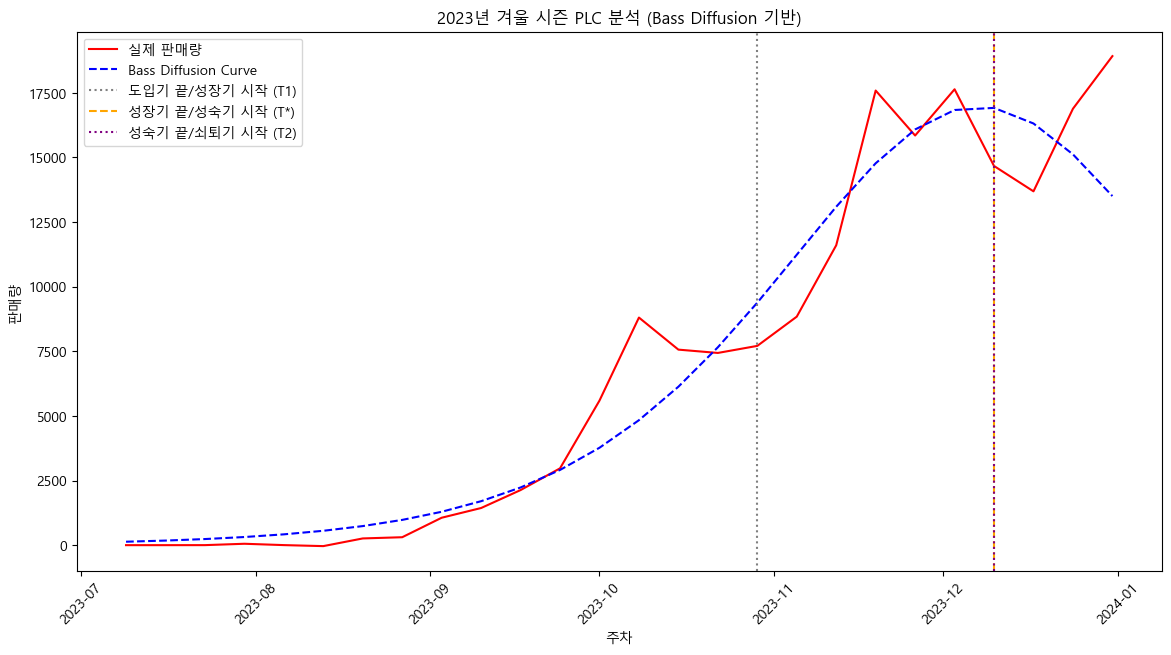

In [107]:
# ✅ 겨울 2024년만 추출
# winter_2024 = plc_df[(plc_df['시즌'] == '겨울') & (plc_df['연도'] == 2024)].iloc[0]
winter_2024 = plc_df[(plc_df['시즌'] == '겨울') & (plc_df['연도'] == 2023)].iloc[0]

# ✅ 원본 데이터에서 겨울 2024년 다시 불러오기
# df_winter_2024 = df[(df['시즌'] == '겨울') & (df['주차'].dt.year == 2024)].copy()
df_winter_2024 = df[(df['시즌'] == '겨울') & (df['주차'].dt.year == 2023)].copy()
df_sales = df_winter_2024.groupby('주차', as_index=False)['판매수량'].sum().sort_values('주차').reset_index(drop=True)

# ✅ Bass Curve 다시 생성 (겨울 2024)
p, q, m_val = winter_2024['p'], winter_2024['q'], winter_2024['m']
time = np.arange(1, len(df_sales) + 1)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# ✅ 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_sales['주차'], df_sales['판매수량'], label='실제 판매량', color='red')
plt.plot(df_sales['주차'], bass_curve, label='Bass Diffusion Curve', color='blue', linestyle='--')
plt.axvline(winter_2024['T1'], color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(winter_2024['T*'], color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(winter_2024['T2'], color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
# plt.title('2024년 겨울 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.title('2023년 겨울 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.show()


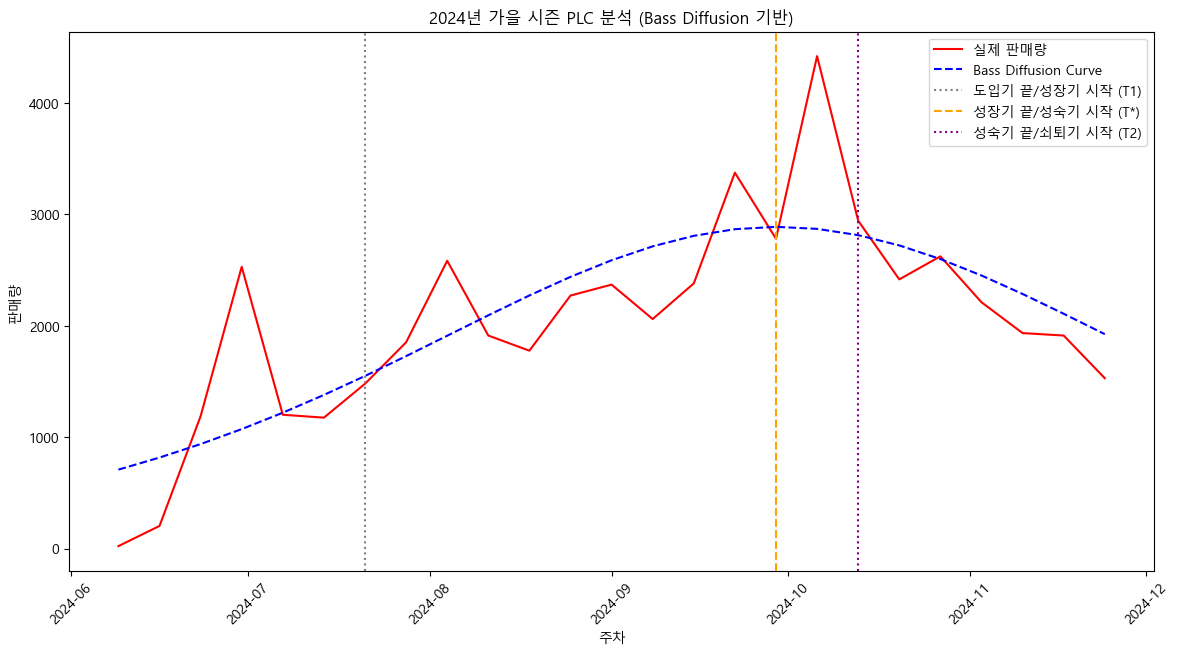

In [146]:
# ✅ 가을 2024년만 추출
# winter_2024 = plc_df[(plc_df['시즌'] == '가을') & (plc_df['연도'] == 2024)].iloc[0]
winter_2024 = plc_df[(plc_df['시즌'] == '가을') & (plc_df['연도'] == 2024)].iloc[0]

# ✅ 원본 데이터에서 가을 2024년 다시 불러오기
# df_winter_2024 = df[(df['시즌'] == '가을') & (df['주차'].dt.year == 2024)].copy()
df_winter_2024 = df[(df['시즌'] == '가을') & (df['주차'].dt.year == 2024)].copy()
df_sales = df_winter_2024.groupby('주차', as_index=False)['판매수량'].sum().sort_values('주차').reset_index(drop=True)

# ✅ Bass Curve 다시 생성 (가을 2024)
p, q, m_val = winter_2024['p'], winter_2024['q'], winter_2024['m']
time = np.arange(1, len(df_sales) + 1)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# ✅ 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_sales['주차'], df_sales['판매수량'], label='실제 판매량', color='red')
plt.plot(df_sales['주차'], bass_curve, label='Bass Diffusion Curve', color='blue', linestyle='--')
plt.axvline(winter_2024['T1'], color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(winter_2024['T*'], color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(winter_2024['T2'], color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
# plt.title('2024년 가을 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.title('2024년 가을 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.show()


# 봄

## 최적 하이퍼파라미터 선정

Train shape: (66, 2), Test shape: (21, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.7, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.7, SPS=4...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.8, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.8, SPS=4...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=0.8, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=1, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=1, SPS=4...
🔹 Testing Seasonality=multiplicative, CPS=0.1, CPR=1, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.7, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.7, SPS=4...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.8, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.8, SPS=4...
🔹 Testing Seasonality=multiplicative, CPS=0.2, CPR=0.8

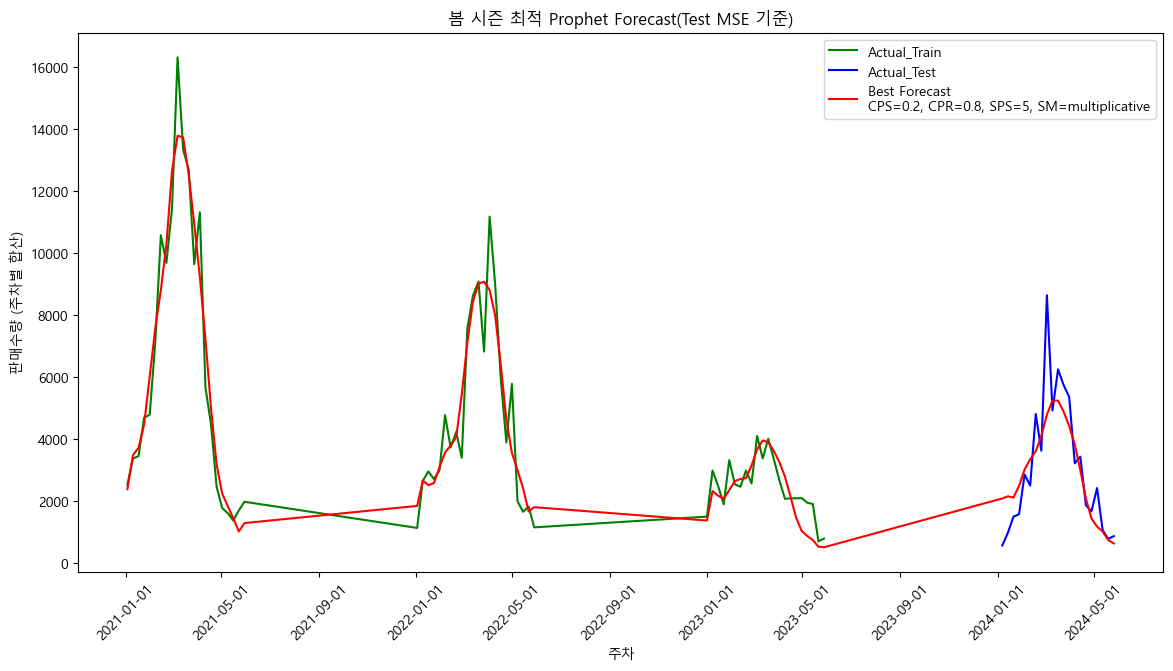


🔹 2024년 실제 총 판매량 (봄): 64620 장
🔹 2024년 Prophet 예측 총 판매량 (봄): 61377 장


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '봄' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '봄'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.1, 0.2, 0.3] #기본값 0.05
changepoint_range_list = [0.7, 0.8, 1] #기본값 0.8
seasonality_prior_scale_list = [3,4,5] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'봄 시즌 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 (봄): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 (봄): {forecast_sales_2024:.0f} 장")


## 25년 예측


2024년 '봄' 총 판매량: 64418 장
2024년 '봄' 총 입고수량: 87587 장
최종 학습 데이터 Shape (봄): (87, 2)

🔹 2025년 '봄' 총 예상 판매량 : 101587 장
🔹 2025년 '봄' 입고 계획량 (예비 20% 포함): 121905 장


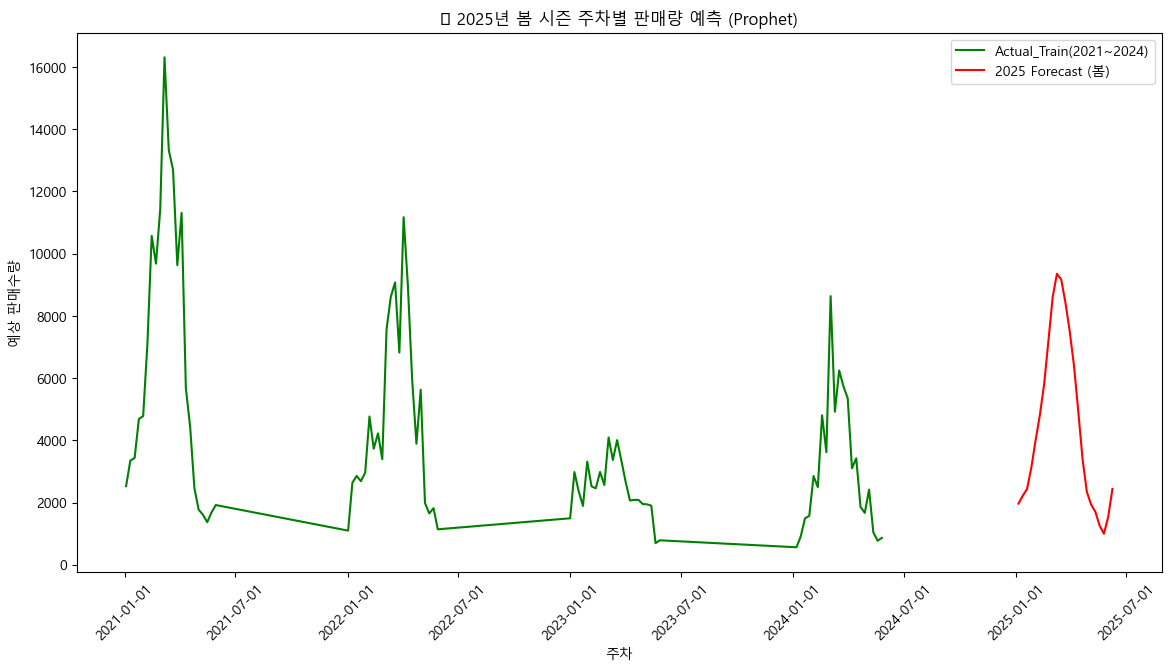

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '봄' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '봄'].copy()

# 2024년 '봄' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '봄' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '봄' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (봄): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.2,
    changepoint_range=0.8,
    seasonality_prior_scale=4, #현실성 확보와 peak 발생 방지를 위해 하향 조정
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-06-01', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '봄' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '봄' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '봄' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (봄)', color='red')
plt.title('🔹 2025년 봄 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 여름

## 최적 파라미터 선정

Train shape: (113, 2), Test shape: (39, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.7, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.7, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.7, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.7, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.8, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.8, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.8, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.8, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.8, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.9, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.9, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.9, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.9, SPS=30...
🔹 Testing Seasonality=multiplicative

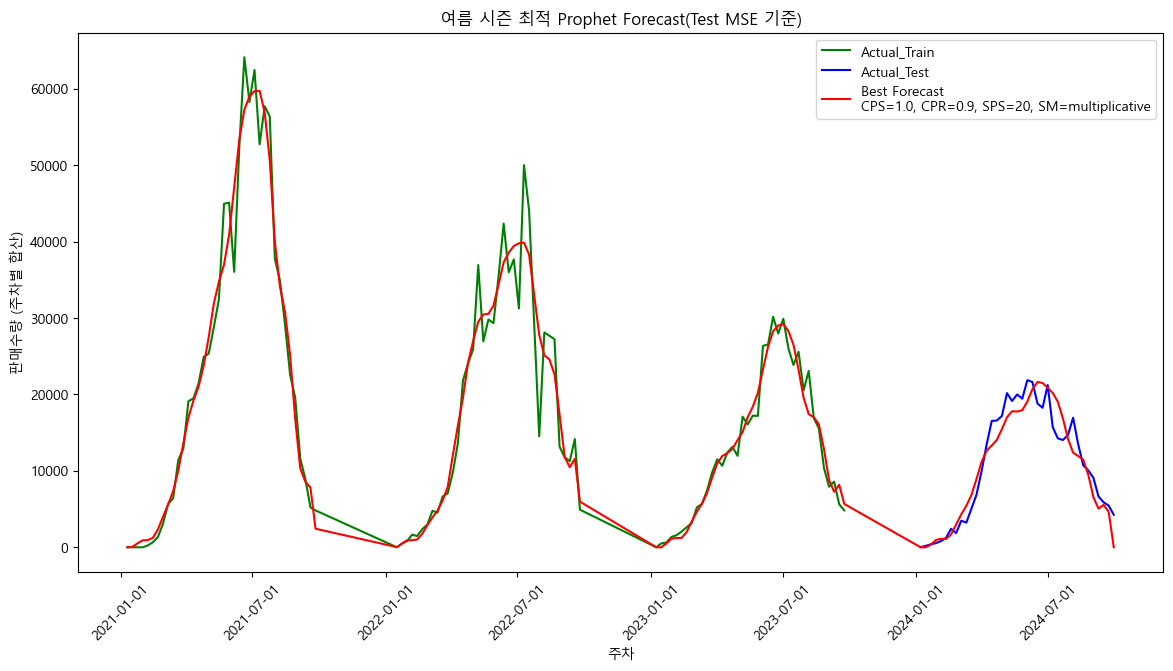


🔹 2024년 실제 총 판매량 (여름): 421620 장
🔹 2024년 Prophet 예측 총 판매량 (여름): 411842 장


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '여름' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '여름'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.6, 0.8, 0.9, 1] #기본값 0.05
changepoint_range_list = [0.7, 0.8, 0.9, 1] #기본값 0.8
seasonality_prior_scale_list = [5, 10, 20, 30, 40] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'여름 시즌 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 (여름): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 (여름): {forecast_sales_2024:.0f} 장")


## 25년 예측


2024년 '여름' 총 판매량: 421584 장
2024년 '여름' 총 입고수량: 548949 장
최종 학습 데이터 Shape (여름): (152, 2)

🔹 2025년 '여름' 총 예상 판매량 : 443813 장
🔹 2025년 '여름' 입고 계획량 (예비 20% 포함): 532575 장


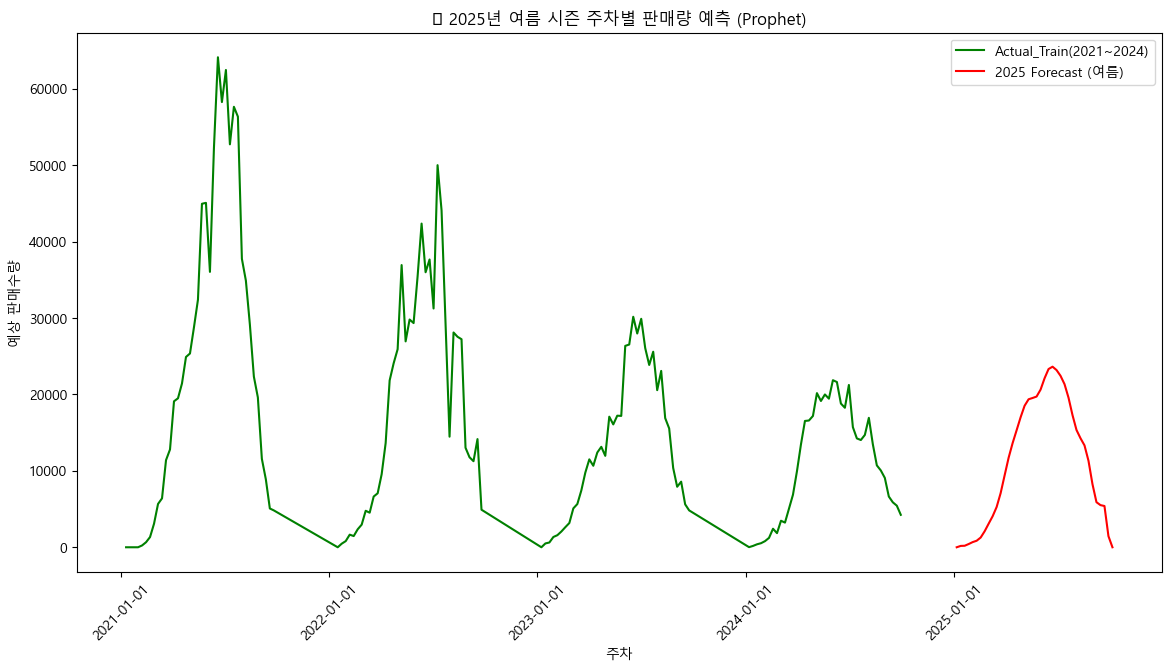

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '여름' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '여름'].copy()

# 2024년 '여름' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '여름' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '여름' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (여름): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=1,
    changepoint_range=0.9,
    seasonality_prior_scale=20, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-10-05', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '여름' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '여름' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '여름' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (여름)', color='red')
plt.title('🔹 2025년 여름 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


In [141]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])

# ✅ 변수로 시즌/연도 입력
target_season = '여름'  # '여름', '겨울', '봄', '가을', '사계절' 등으로 변경
target_year = 2024
total_inbound_plan = 532575   # Prophet 예측 결과 입고 계획량 입력

# ✅ 복종 필터 리스트
target_categories = ["가죽&FUR", "니트 셔츠", "데님", "사파리", "수트", 
                     "스웨터", "우븐 셔츠", "자켓", "점퍼", "조끼", "코트", "팬츠"]

# ✅ 시즌 & 연도 & 복종 필터링
df_season = df[(df['주차'].dt.year == target_year) & 
               (df['시즌'] == target_season) & 
               (df['복종'].isin(target_categories))].copy()

# ✅ 복종별 판매수량 집계
category_sales = df_season.groupby('복종')['판매수량'].sum().reset_index()

# ✅ 전체 판매량
total_sales = category_sales['판매수량'].sum()

# ✅ 복종별 판매비중 계산
category_sales['판매비중'] = category_sales['판매수량'] / total_sales

print(f"\n✅ {target_year}년 {target_season} 시즌 복종별 판매 비중 (%)")
print(category_sales[['복종', '판매비중']].sort_values(by='판매비중', ascending=False))

# ✅ 복종별 입고계획 수량 계산
category_sales['입고계획수량'] = (category_sales['판매비중'] * total_inbound_plan).astype(int)

print(f"\n✅ {target_year+1}년 {target_season} 시즌 복종별 입고계획 수량 (예측 입고 총량: {total_inbound_plan:,}장)")
print(category_sales[['복종', '입고계획수량']].sort_values(by='입고계획수량', ascending=False))



✅ 2024년 여름 시즌 복종별 판매 비중 (%)
      복종      판매비중
0  니트 셔츠  0.264322
6     팬츠  0.238458
2    스웨터  0.174314
1     수트  0.127002
3  우븐 셔츠  0.113686
4     자켓  0.044710
5     점퍼  0.037509

✅ 2025년 여름 시즌 복종별 입고계획 수량 (예측 입고 총량: 532,575장)
      복종  입고계획수량
0  니트 셔츠  140771
6     팬츠  126996
2    스웨터   92835
1     수트   67638
3  우븐 셔츠   60546
4     자켓   23811
5     점퍼   19976



✅ Bass Model Parameters → p: 0.0014, q: 0.2113, m: 460919

📌 도입기 끝/성장기 시작 (T1): 2025-04-20 (판매량 12574 장)
📌 성장기 끝/성숙기 시작 (T*): 2025-06-15 (판매량 24633 장)
📌 성숙기 끝/쇠퇴기 시작 (T2): 2025-07-13 (판매량 20963 장)

✅ PLC 구간별 누적 판매량 (장):
도입기: 60460 장
성장기: 152187 장
성숙기: 95339 장
쇠퇴기: 138991 장


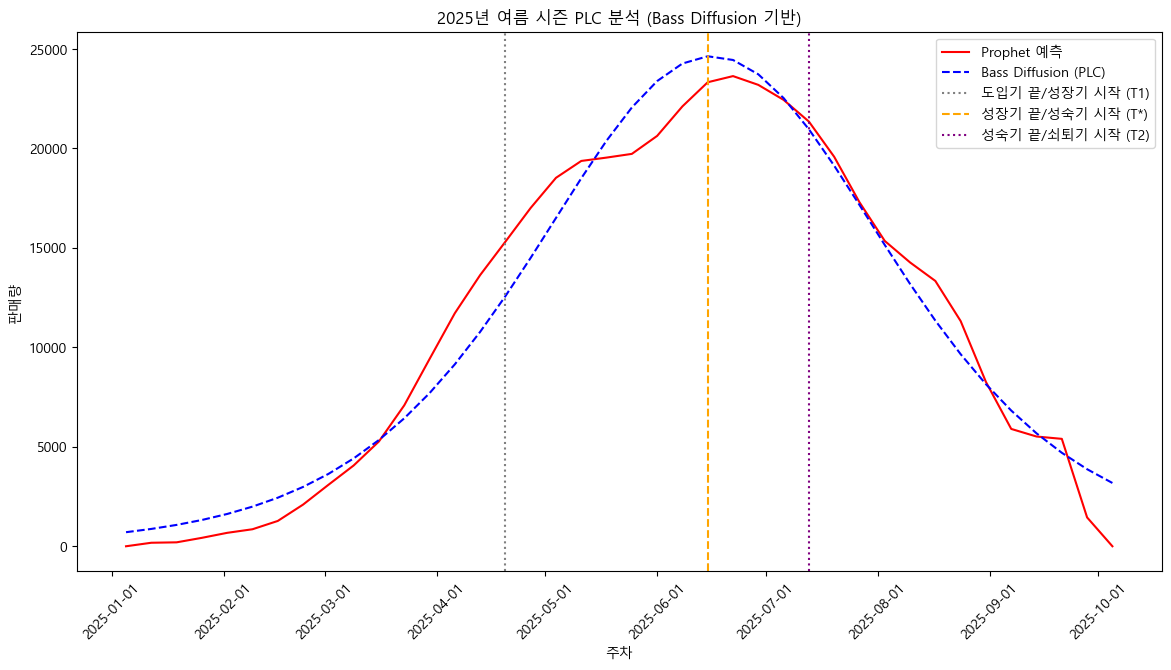

In [ ]:
from scipy.optimize import curve_fit

# Prophet 예측 판매량으로 Bass 모델 fitting
sales_array = forecast_2025['yhat'].values
time = np.arange(1, len(sales_array) + 1)

# Bass 누적 모델 정의 (cumulative로 curve_fit)
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

cumulative_sales = np.cumsum(sales_array)
params, _ = curve_fit(bass_cumulative, time, cumulative_sales, bounds=(0, [1, 1, 1e7]))
p, q, m_val = params

print(f"\nBass Model Parameters → p: {p:.4f}, q: {q:.4f}, m: {m_val:.0f}")

# Bass 곡선 생성 (순판매량으로 변환)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
T_star_week = forecast_2025['ds'].iloc[T_star_idx]
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T1_week = forecast_2025['ds'].iloc[T1_idx]

total_bass_sales = np.sum(bass_curve)
target_cumulative = total_bass_sales * 0.7
cumulative_bass = np.cumsum(bass_curve)

# 누적 판매량이 70% 넘는 지점 찾기
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]
T2_week = forecast_2025['ds'].iloc[T2_idx]

print(f"\n도입기 끝/성장기 시작 (T1): {T1_week.date()} (판매량 {bass_curve[T1_idx]:.0f} 장)")
print(f"성장기 끝/성숙기 시작 (T*): {T_star_week.date()} (판매량 {bass_curve[T_star_idx]:.0f} 장)")
print(f"성숙기 끝/쇠퇴기 시작 (T2): {T2_week.date()} (판매량 {bass_curve[T2_idx]:.0f} 장)")

# PLC 구간별 누적 판매량 계산
intro_sales = np.sum(bass_curve[:T1_idx])
growth_sales = np.sum(bass_curve[T1_idx:T_star_idx])
mature_sales = np.sum(bass_curve[T_star_idx:T2_idx])
decline_sales = np.sum(bass_curve[T2_idx:])

print("\nPLC 구간별 누적 판매량 (장):")
print(f"도입기: {intro_sales:.0f} 장")
print(f"성장기: {growth_sales:.0f} 장")
print(f"성숙기: {mature_sales:.0f} 장")
print(f"쇠퇴기: {decline_sales:.0f} 장")

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(forecast_2025['ds'], sales_array, label='Prophet 예측', color='red')
plt.plot(forecast_2025['ds'], bass_curve, label='Bass Diffusion (PLC)', color='blue', linestyle='--')
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
plt.title('2025년 여름 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 가을

## 최적 파라미터 선정

Train shape: (63, 2), Test shape: (25, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.4, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.4, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.4, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.4, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.5, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.5, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.5, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.5, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.7, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.7, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.7, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.8, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.7, CPR=0.8, SPS=10...
🔹 Testing Seasonality=multiplicative, 

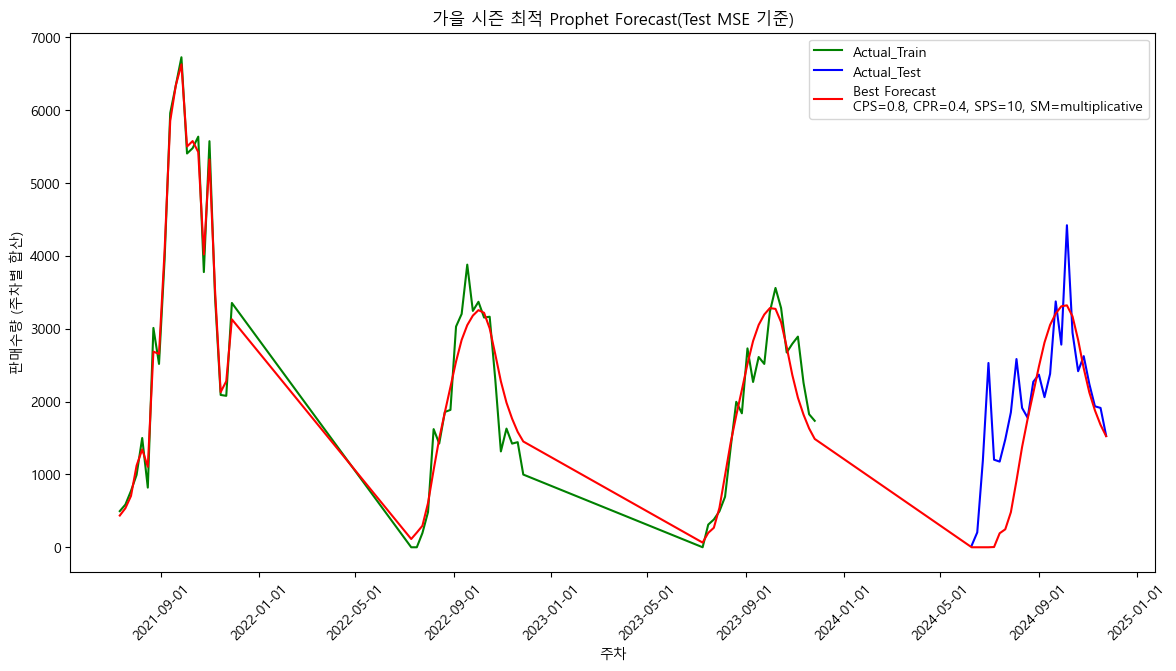


🔹 2024년 실제 총 판매량 (가을): 51196 장
🔹 2024년 Prophet 예측 총 판매량 (가을): 40963 장


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '가을'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.7, 0.8, 0.9, 1] #기본값 0.05
changepoint_range_list = [0.4, 0.5,0.7,0.8,0.9] #기본값 0.8
seasonality_prior_scale_list = [5, 10, 20, 30] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'가을 시즌 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 (가을): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 (가을): {forecast_sales_2024:.0f} 장")


## 25년 예측


2024년 '가을' 총 판매량: 51167 장
2024년 '가을' 총 입고수량: 87877 장
최종 학습 데이터 Shape (가을): (88, 2)

🔹 2025년 '가을' 총 예상 판매량 : 64254 장
🔹 2025년 '가을' 입고 계획량 (예비 20% 포함): 77104 장


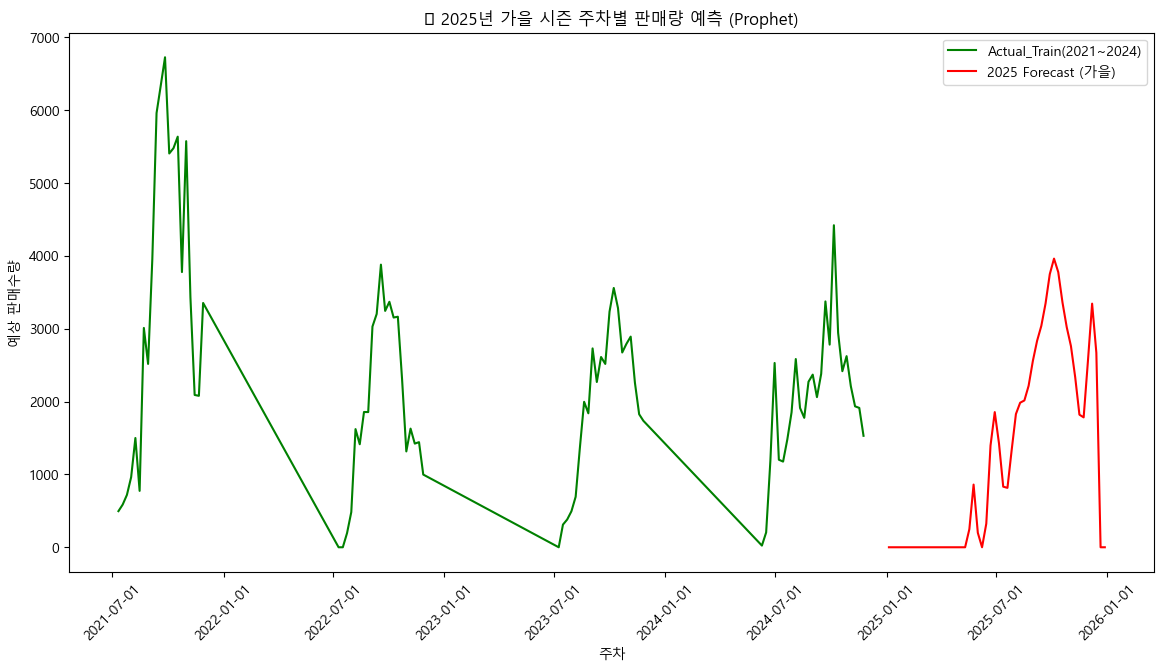

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '가을'].copy()

# 2024년 '가을' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '가을' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '가을' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (가을): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.8,
    changepoint_range=0.4,
    seasonality_prior_scale=10, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '가을' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '가을' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '가을' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (가을)', color='red')
plt.title('🔹 2025년 가을 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()



✅ Bass Model Parameters → p: 0.0001, q: 0.1994, m: 70274

📌 도입기 끝/성장기 시작 (T1): 2025-08-10 (판매량 1940 장)
📌 성장기 끝/성숙기 시작 (T*): 2025-10-05 (판매량 3502 장)
📌 성숙기 끝/쇠퇴기 시작 (T2): 2025-10-26 (판매량 3226 장)

✅ PLC 구간별 누적 판매량 (장):
도입기: 10694 장
성장기: 22330 장
성숙기: 10356 장
쇠퇴기: 21428 장


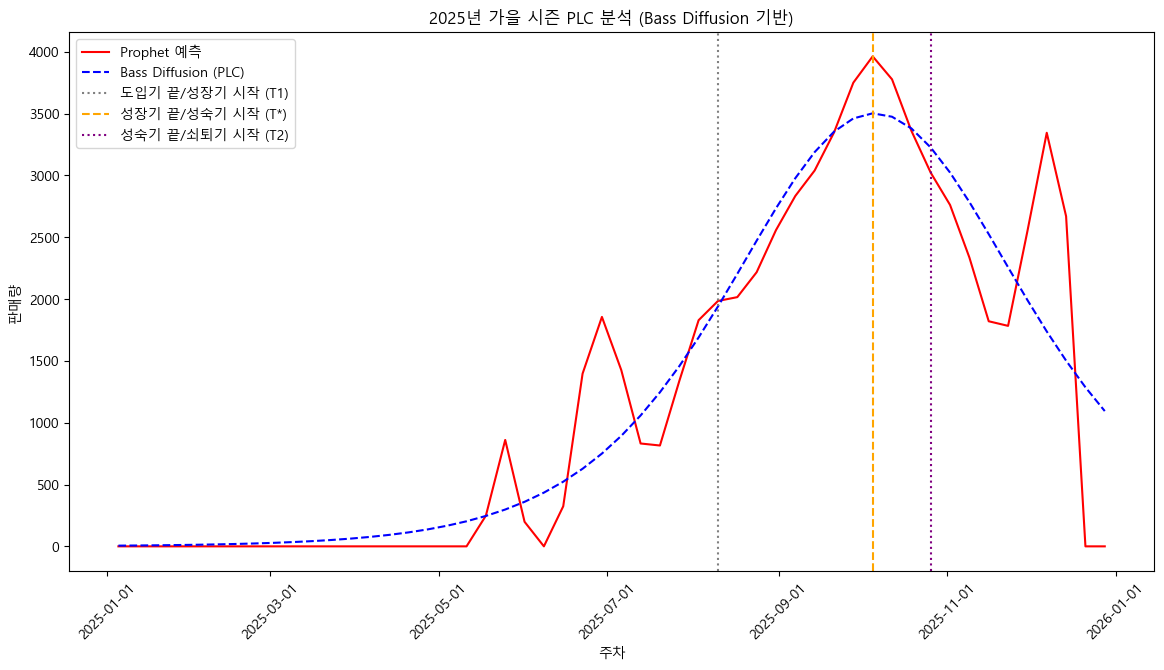

In [ ]:
from scipy.optimize import curve_fit

# Prophet 예측 판매량으로 Bass 모델 fitting
sales_array = forecast_2025['yhat'].values
time = np.arange(1, len(sales_array) + 1)

# Bass 누적 모델 정의 (cumulative로 curve_fit)
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

cumulative_sales = np.cumsum(sales_array)
params, _ = curve_fit(bass_cumulative, time, cumulative_sales, bounds=(0, [1, 1, 1e7]))
p, q, m_val = params

print(f"\nBass Model Parameters → p: {p:.4f}, q: {q:.4f}, m: {m_val:.0f}")

# Bass 곡선 생성 (순판매량으로 변환)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
T_star_week = forecast_2025['ds'].iloc[T_star_idx]
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T1_week = forecast_2025['ds'].iloc[T1_idx]

total_bass_sales = np.sum(bass_curve)
target_cumulative = total_bass_sales * 0.7
cumulative_bass = np.cumsum(bass_curve)

# 누적 판매량이 70% 넘는 지점 찾기
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]
T2_week = forecast_2025['ds'].iloc[T2_idx]

print(f"\n 도입기 끝/성장기 시작 (T1): {T1_week.date()} (판매량 {bass_curve[T1_idx]:.0f} 장)")
print(f" 성장기 끝/성숙기 시작 (T*): {T_star_week.date()} (판매량 {bass_curve[T_star_idx]:.0f} 장)")
print(f" 성숙기 끝/쇠퇴기 시작 (T2): {T2_week.date()} (판매량 {bass_curve[T2_idx]:.0f} 장)")

# PLC 구간별 누적 판매량 계산
intro_sales = np.sum(bass_curve[:T1_idx])
growth_sales = np.sum(bass_curve[T1_idx:T_star_idx])
mature_sales = np.sum(bass_curve[T_star_idx:T2_idx])
decline_sales = np.sum(bass_curve[T2_idx:])

print("\nPLC 구간별 누적 판매량 (장):")
print(f"도입기: {intro_sales:.0f} 장")
print(f"성장기: {growth_sales:.0f} 장")
print(f"성숙기: {mature_sales:.0f} 장")
print(f"쇠퇴기: {decline_sales:.0f} 장")

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(forecast_2025['ds'], sales_array, label='Prophet 예측', color='red')
plt.plot(forecast_2025['ds'], bass_curve, label='Bass Diffusion (PLC)', color='blue', linestyle='--')
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
plt.title('2025년 가을 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 겨울

Train shape: (70, 2), Test shape: (24, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.2, SPS=7...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.2, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.2, SPS=15...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.2, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.2, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.3, SPS=7...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.3, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.3, SPS=15...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.3, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.3, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.4, SPS=7...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.4, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.4, SPS=15...
🔹 Testing Seasonality=multiplicative, CPS=0.8, CPR=0.4, SPS=20...
🔹 Testing Seasonality=multiplicative,

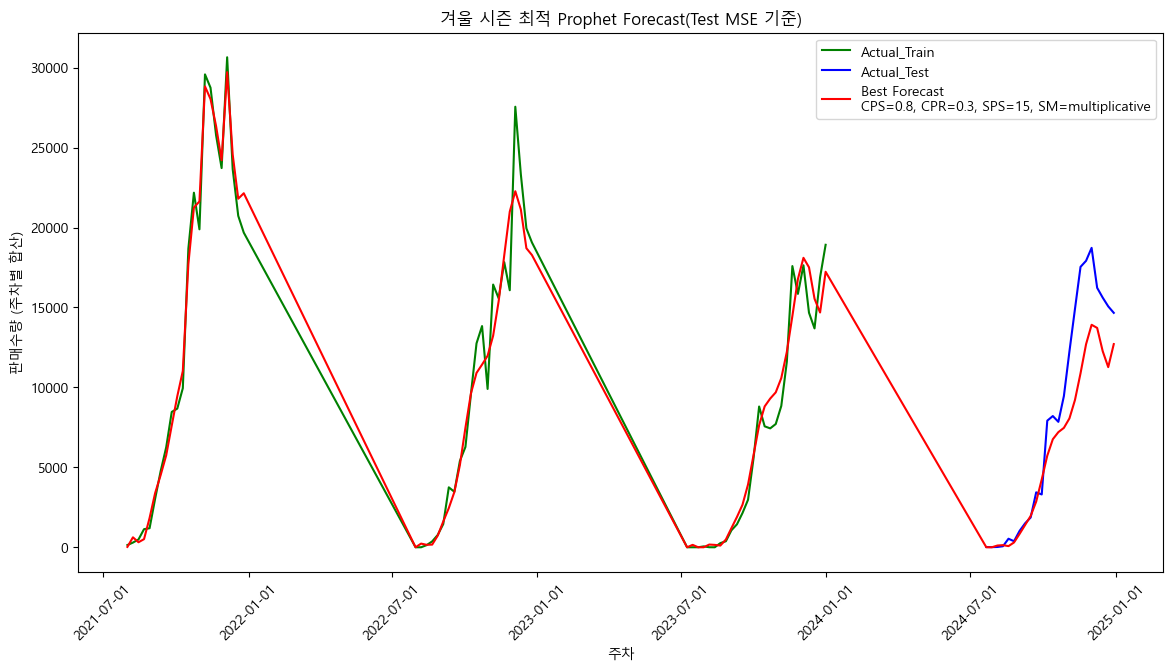


🔹 2024년 실제 총 판매량 (겨울): 188485 장
🔹 2024년 Prophet 예측 총 판매량 (겨울): 143792 장


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '겨울' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '겨울'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.8, 0.9, 1] #기본값 0.05
changepoint_range_list = [0.2,0.3,0.4] #기본값 0.8
seasonality_prior_scale_list = [7,10,15,20,30] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'겨울 시즌 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 (겨울): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 (겨울): {forecast_sales_2024:.0f} 장")



2024년 '겨울' 총 판매량: 188473 장
2024년 '겨울' 총 입고수량: 375768 장
최종 학습 데이터 Shape (겨울): (94, 2)

🔹 2025년 '겨울' 총 예상 판매량 : 193058 장
🔹 2025년 '겨울' 입고 계획량 (예비 20% 포함): 231670 장


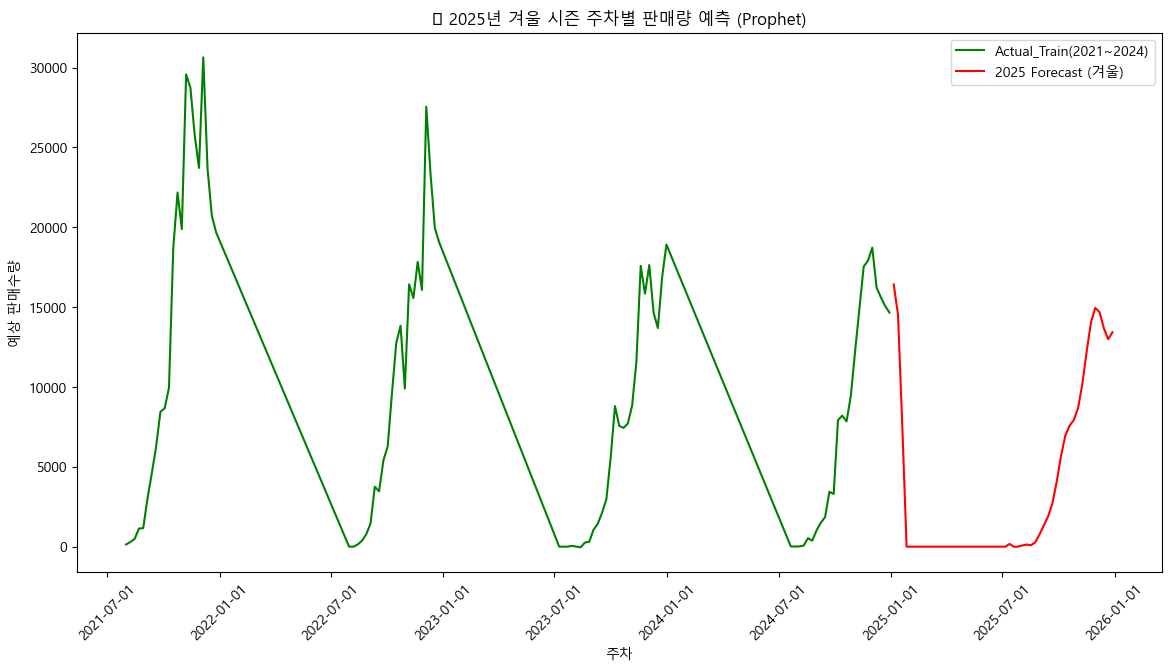

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '겨울'].copy()

# 2024년 '겨울' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '겨울' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '겨울' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (겨울): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.8,
    changepoint_range=0.3,
    seasonality_prior_scale=15, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '겨울' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '겨울' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '겨울' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (겨울)', color='red')
plt.title('🔹 2025년 겨울 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()



✅ Bass Model Parameters → p: 0.0001, q: 0.2058, m: 62893

📌 도입기 끝/성장기 시작 (T1): 2025-08-10 (판매량 1817 장)
📌 성장기 끝/성숙기 시작 (T*): 2025-10-05 (판매량 3233 장)
📌 성숙기 끝/쇠퇴기 시작 (T2): 2025-10-26 (판매량 2899 장)

✅ PLC 구간별 누적 판매량 (장):
도입기: 9714 장
성장기: 20920 장
성숙기: 9483 장
쇠퇴기: 18528 장


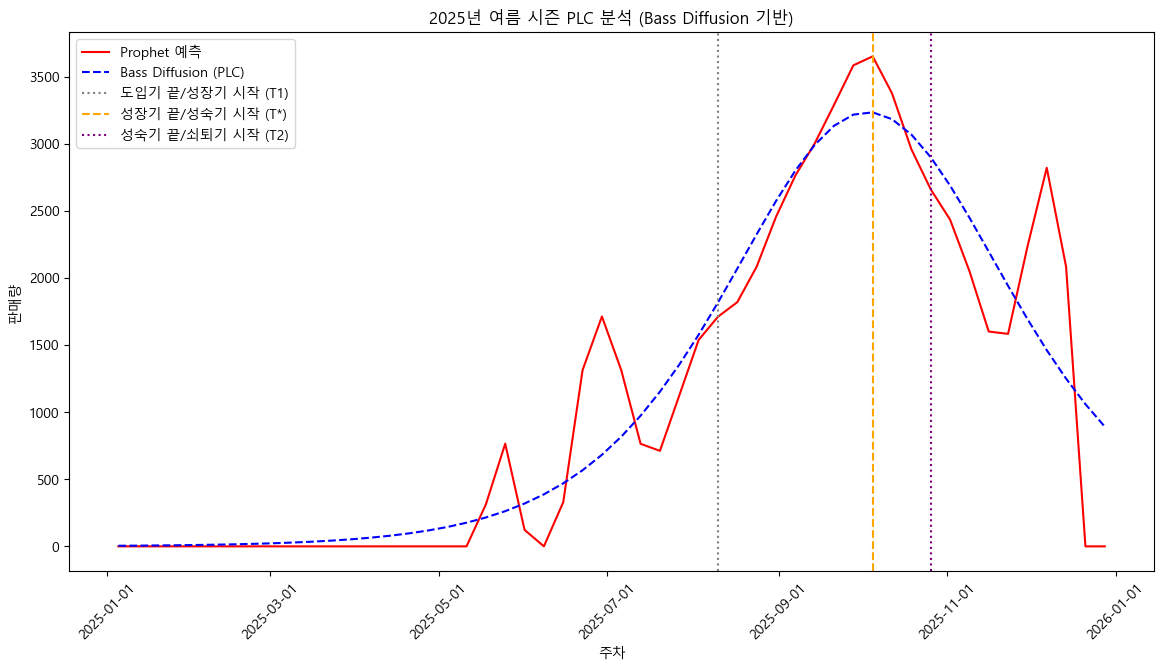

In [96]:
from scipy.optimize import curve_fit

# ✅ Prophet 예측 판매량으로 Bass 모델 fitting
sales_array = forecast_2025['yhat'].values
time = np.arange(1, len(sales_array) + 1)

# ✅ Bass 누적 모델 정의 (cumulative로 curve_fit)
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

cumulative_sales = np.cumsum(sales_array)
params, _ = curve_fit(bass_cumulative, time, cumulative_sales, bounds=(0, [1, 1, 1e7]))
p, q, m_val = params

print(f"\n✅ Bass Model Parameters → p: {p:.4f}, q: {q:.4f}, m: {m_val:.0f}")

# ✅ Bass 곡선 생성 (순판매량으로 변환)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# ✅ PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
T_star_week = forecast_2025['ds'].iloc[T_star_idx]
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T1_week = forecast_2025['ds'].iloc[T1_idx]

total_bass_sales = np.sum(bass_curve)
target_cumulative = total_bass_sales * 0.7
cumulative_bass = np.cumsum(bass_curve)

# 누적 판매량이 70% 넘는 지점 찾기
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]
T2_week = forecast_2025['ds'].iloc[T2_idx]

print(f"\n📌 도입기 끝/성장기 시작 (T1): {T1_week.date()} (판매량 {bass_curve[T1_idx]:.0f} 장)")
print(f"📌 성장기 끝/성숙기 시작 (T*): {T_star_week.date()} (판매량 {bass_curve[T_star_idx]:.0f} 장)")
print(f"📌 성숙기 끝/쇠퇴기 시작 (T2): {T2_week.date()} (판매량 {bass_curve[T2_idx]:.0f} 장)")

# ✅ PLC 구간별 누적 판매량 계산
intro_sales = np.sum(bass_curve[:T1_idx])
growth_sales = np.sum(bass_curve[T1_idx:T_star_idx])
mature_sales = np.sum(bass_curve[T_star_idx:T2_idx])
decline_sales = np.sum(bass_curve[T2_idx:])

print("\n✅ PLC 구간별 누적 판매량 (장):")
print(f"도입기: {intro_sales:.0f} 장")
print(f"성장기: {growth_sales:.0f} 장")
print(f"성숙기: {mature_sales:.0f} 장")
print(f"쇠퇴기: {decline_sales:.0f} 장")

# ✅ 시각화
plt.figure(figsize=(14, 7))
plt.plot(forecast_2025['ds'], sales_array, label='Prophet 예측', color='red')
plt.plot(forecast_2025['ds'], bass_curve, label='Bass Diffusion (PLC)', color='blue', linestyle='--')
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
plt.title('2025년 여름 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 사계절

## 최적 파라미터 선정

Train shape: (157, 2), Test shape: (52, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.6, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.6, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.6, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.6, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.6, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.7, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.7, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.7, SPS=20...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.7, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.8, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.8, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.8, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.01, CPR=0.8, SPS=20...
🔹 Testing Seasonality=mul

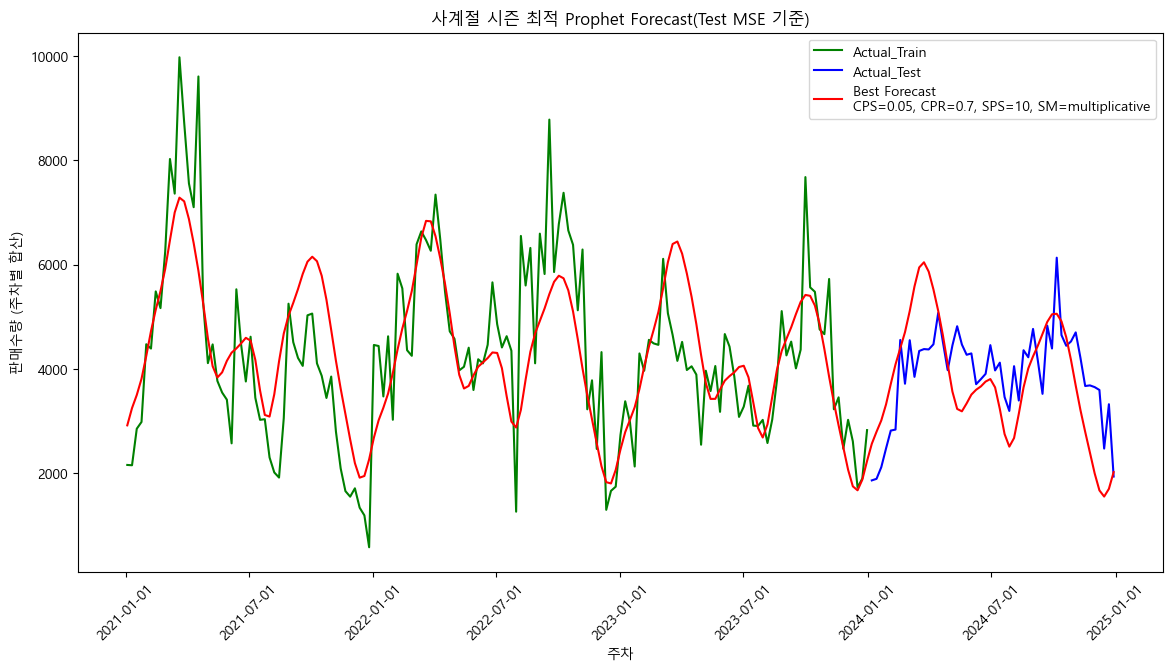


🔹 2024년 실제 총 판매량 (사계절): 203472 장
🔹 2024년 Prophet 예측 총 판매량 (사계절): 196898 장


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '사계절' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '사계절'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.01,0.05, 0.1, 0.2] #기본값 0.05
changepoint_range_list = [0.6, 0.7, 0.8, 0.9, 1] #기본값 0.8
seasonality_prior_scale_list = [1, 5, 10, 20, 30] #기본값 10
seasonality_modes = ['multiplicative'] #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'사계절 시즌 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 (사계절): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 (사계절): {forecast_sales_2024:.0f} 장")

## 25년 예측


2024년 '사계절' 총 판매량: 51167 장
2024년 '사계절' 총 입고수량: 87877 장
최종 학습 데이터 Shape (사계절): (88, 2)

🔹 2025년 '사계절' 총 예상 판매량 : 59215 장
🔹 2025년 '사계절' 입고 계획량 (예비 20% 포함): 71058 장


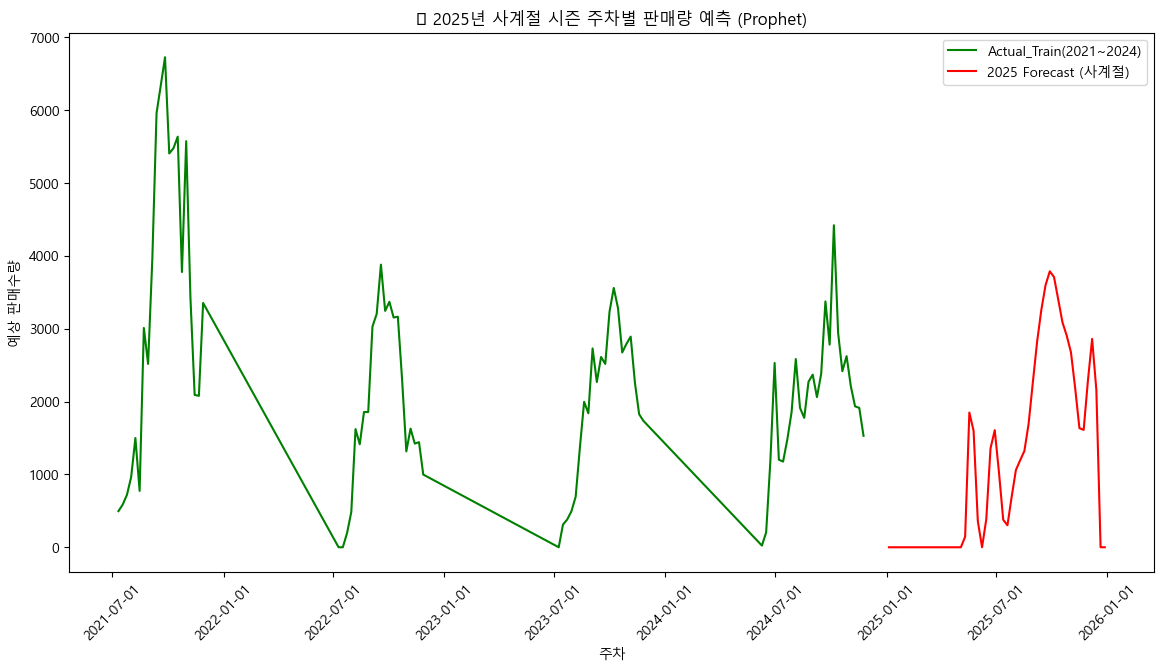

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '가을'].copy()

# 2024년 '사계절' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '사계절' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '사계절' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (사계절): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.05,
    changepoint_range=0.7,
    seasonality_prior_scale=10, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '사계절' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '사계절' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '사계절' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (사계절)', color='red')
plt.title('🔹 2025년 사계절 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


## 겨울_패딩사파리

Train shape: (53, 2), Test shape: (14, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.4, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.4, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.4, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.5, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.6, CPR=0.5, SPS=40...
🔹 Testing Seasonality=multiplicati

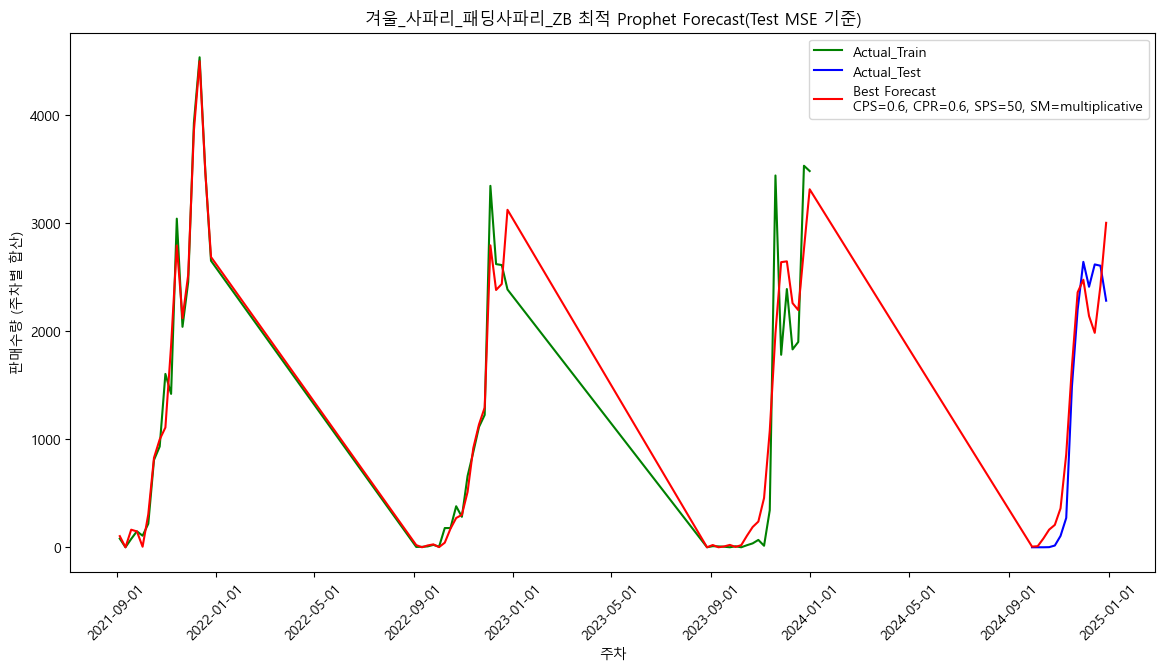


🔹 2024년 실제 총 판매량 ('겨울_사파리_패딩사파리_ZB'): 16653 장
🔹 2024년 Prophet 예측 총 판매량 ('겨울_사파리_패딩사파리_ZB'): 17761 장


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '겨울_사파리_패딩사파리_ZB' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_사파리_패딩사파리_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5,0.6] #기본값 0.05
changepoint_range_list = [0.4, 0.5, 0.6] #기본값 0.8
seasonality_prior_scale_list = [30,40,50] #기본값 10
seasonality_modes = ['multiplicative']  #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'겨울_사파리_패딩사파리_ZB 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 ('겨울_사파리_패딩사파리_ZB'): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 ('겨울_사파리_패딩사파리_ZB'): {forecast_sales_2024:.0f} 장")

Train shape: (53, 2), 11월 Test shape: (4, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=100...
🔹 Testing Seasonality=mult

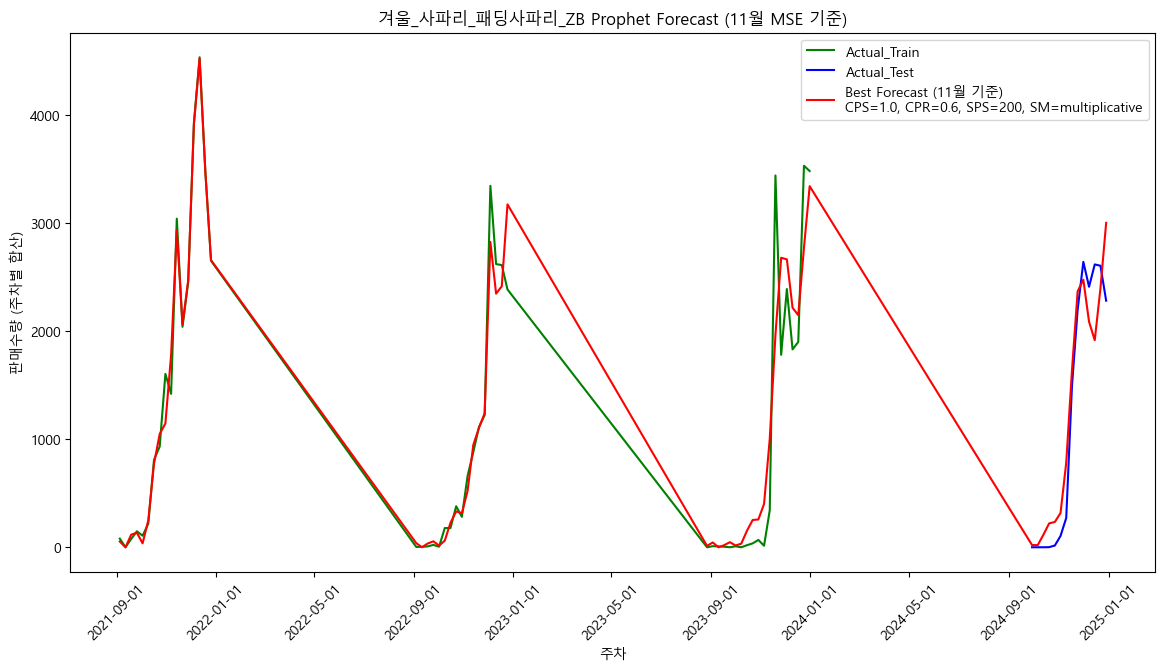


🔹 2024년 11월 실제 판매량: 4067 장
🔹 2024년 11월 Prophet 예측 판매량: 5106 장


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '겨울_사파리_패딩사파리_ZB' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_사파리_패딩사파리_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

# 2024년 11월만 따로 추출 (← 핵심 변경)
test_data_nov = test_data[
    (test_data['ds'] >= pd.to_datetime('2024-11-01')) & 
    (test_data['ds'] <= pd.to_datetime('2024-11-30'))
].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, 11월 Test shape: {test_data_nov.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5, 0.6,0.7,0.8,1]
changepoint_range_list = [0.4, 0.5, 0.6,0.7,0.8,1]
seasonality_prior_scale_list = [30, 40, 50,100,200]
seasonality_modes = ['multiplicative']
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])
                future = df[['ds']].copy()
                forecast = m.predict(future)

                # 핵심: 11월만 평가
                mse, rmse = get_metrics(test_data_nov, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n🔍 2024년 11월 예측 MSE 기준 최적 조합:")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast (11월 기준)\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'겨울_사파리_패딩사파리_ZB Prophet Forecast (11월 MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 11월 실제 vs 예측 총합 비교
actual_sales_nov = test_data_nov['y'].sum()
forecast_sales_nov = best_forecast[
    (best_forecast['ds'] >= '2024-11-01') & 
    (best_forecast['ds'] <= '2024-11-30')
]['yhat'].sum()

print(f"\n🔹 2024년 11월 실제 판매량: {actual_sales_nov:.0f} 장")
print(f"🔹 2024년 11월 Prophet 예측 판매량: {forecast_sales_nov:.0f} 장")


In [31]:
# 1. Prophet 예측 결과에서 2024년 주차별 예측값만 추출
forecast_2024 = best_forecast[best_forecast['ds'].dt.year == 2024][['ds', 'yhat']].rename(
    columns={'ds': '주차', 'yhat': 'T_주차예측판매량'})

# 2. 원본 df 불러오기 + 카테고리 필터링 + 2024년만 선택
df_raw = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df_raw['주차'] = pd.to_datetime(df_raw['주차'])
df_2024 = df_raw[(df_raw['카테고리'] == '겨울_사파리_패딩사파리_ZB') & 
                 (df_raw['주차'].dt.year == 2024)].copy()

# ✅ 3. 주차 기준으로 예측값 바로 merge
df_2024 = pd.merge(df_2024, forecast_2024, on='주차', how='left')

# ✅ 4. 매출 및 순이익 계산
df_2024['T_예측매출'] = df_2024['T_주차예측판매량'] * df_2024['주차별_평균_실판매가']
df_2024['T_예측순이익'] = (df_2024['주차별_평균_실판매가'] - df_2024['평균원가']) * df_2024['T_주차예측판매량']

# ✅ 5. 누적합 계산
df_2024['T_누적예측판매량'] = df_2024['T_주차예측판매량'].cumsum()
df_2024['T_누적예측매출'] = df_2024['T_예측매출'].cumsum()
df_2024['T_누적예측순이익'] = df_2024['T_예측순이익'].cumsum()

# 🔍 확인용 출력 (옵션)
df_2024[['카테고리','주차','주차별_평균_실판매가','총입고수량','판매수량','평균원가','T_주차예측판매량', 'T_누적예측판매량', 'T_누적예측매출', 'T_누적예측순이익']]


,카테고리,주차,주차별_평균_실판매가,총입고수량,판매수량,평균원가,T_주차예측판매량,T_누적예측판매량,T_누적예측매출,T_누적예측순이익
0,겨울_사파리_패딩사파리_ZB,2024-09-29,"399,000",5847,-3,25274,21,21,"8,262,406","7,739,037"
1,겨울_사파리_패딩사파리_ZB,2024-10-06,NaN,5847,0,29263,20,40,NaN,NaN
2,겨울_사파리_패딩사파리_ZB,2024-10-13,NaN,9457,0,29263,117,157,NaN,NaN
3,겨울_사파리_패딩사파리_ZB,2024-10-20,"319,200",10536,1,41395,221,378,"78,884,543","69,202,642"
4,겨울_사파리_패딩사파리_ZB,2024-10-27,"319,558",14967,16,55637,234,613,"153,796,815","131,072,230"
5,겨울_사파리_패딩사파리_ZB,2024-11-03,"288,241",19901,105,56388,317,930,"245,273,312","204,653,366"
6,겨울_사파리_패딩사파리_ZB,2024-11-10,"240,814",24449,272,56388,784,"1,713","433,963,355","349,160,537"
7,겨울_사파리_패딩사파리_ZB,2024-11-17,"186,769",25736,1489,56388,"1,635","3,348","739,247,675","562,275,535"
8,겨울_사파리_패딩사파리_ZB,2024-11-24,"180,856",26390,2201,56388,"2,371","5,719","1,167,997,685","857,348,169"
9,겨울_사파리_패딩사파리_ZB,2024-12-01,"183,111",26390,2644,56388,"2,478","8,197","1,621,823,927","1,171,421,178"


Train shape: (99, 2), Test shape: (34, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.5, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.5, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.5, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.5, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.6, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.6, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.6, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.6, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=3...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=5...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.7, SPS=10...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=1...
🔹 Testing Seasonality=multiplicative, CPS=0.05, CPR=0.8, SPS=3...
🔹 Testing Seasonality=multiplic

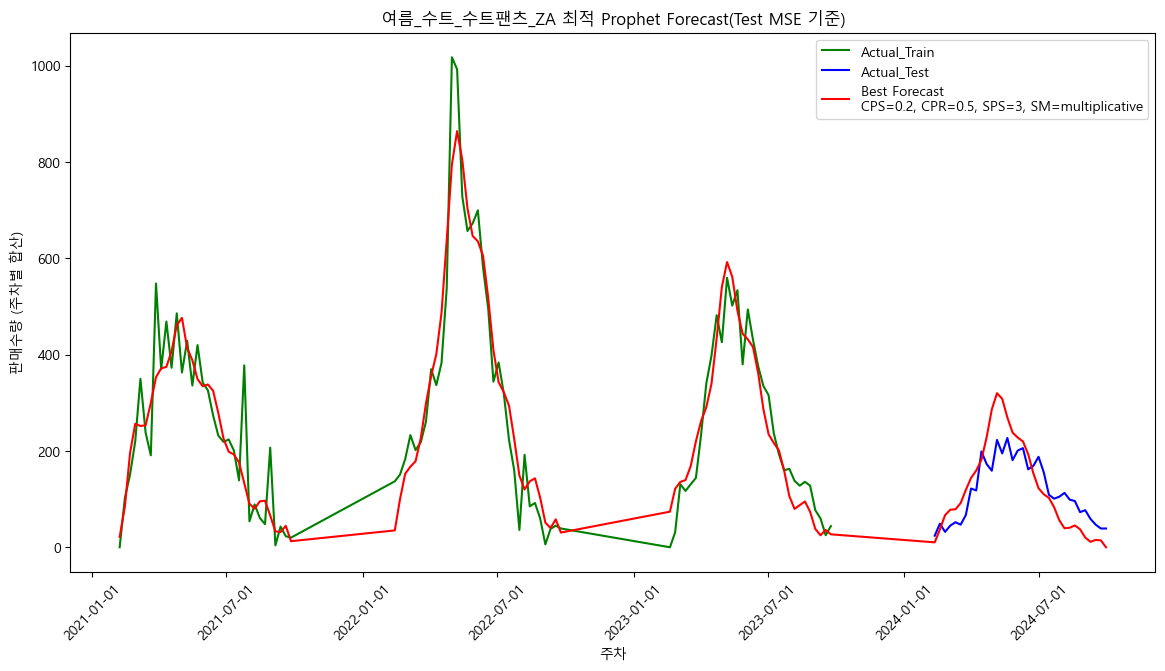


🔹 2024년 실제 총 판매량 ('여름_수트_수트팬츠_ZA'): 3952 장
🔹 2024년 Prophet 예측 총 판매량 ('여름_수트_수트팬츠_ZA'): 4112 장


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '여름_수트_수트팬츠_ZA' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '여름_수트_수트팬츠_ZA'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.05,0.1,0.2,0.3] #기본값 0.05
changepoint_range_list = [0.5,0.6,0.7,0.8] #기본값 0.8
seasonality_prior_scale_list = [1, 3, 5,10] #기본값 10
seasonality_modes = ['multiplicative']  #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'여름_수트_수트팬츠_ZA 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 ('여름_수트_수트팬츠_ZA'): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 ('여름_수트_수트팬츠_ZA'): {forecast_sales_2024:.0f} 장")


2024년 '여름_수트_수트팬츠_ZA' 총 판매량: 3952 장
2024년 '여름_수트_수트팬츠_ZA' 총 입고수량: 6624 장
최종 학습 데이터 Shape (여름_수트_수트팬츠_ZA): (133, 2)

🔹 2025년 '여름_수트_수트팬츠_ZA' 총 예상 판매량 : 11758 장
🔹 2025년 '여름_수트_수트팬츠_ZA' 입고 계획량 (예비 20% 포함): 14109 장


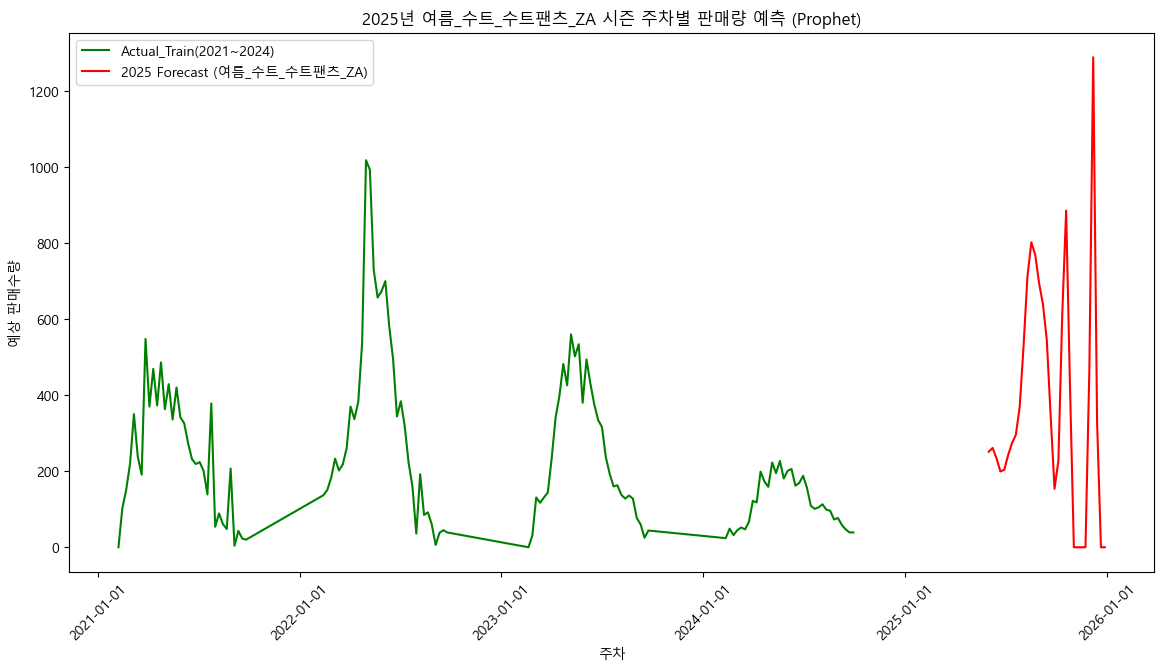

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '겨울패딩사파리'
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '여름_수트_수트팬츠_ZA'].copy()

# 2024년 '여름_수트_수트팬츠_ZA' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '여름_수트_수트팬츠_ZA' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '여름_수트_수트팬츠_ZA' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (여름_수트_수트팬츠_ZA): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=50,
    changepoint_range=1,
    seasonality_prior_scale=10, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-06-01', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '여름_수트_수트팬츠_ZA' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '여름_수트_수트팬츠_ZA' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '여름_수트_수트팬츠_ZA' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (여름_수트_수트팬츠_ZA)', color='red')
plt.title('2025년 여름_수트_수트팬츠_ZA 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


In [35]:
# 1. Prophet 예측 결과에서 2024년 주차별 예측값만 추출
forecast_2024 = best_forecast[best_forecast['ds'].dt.year == 2024][['ds', 'yhat']].rename(
    columns={'ds': '주차', 'yhat': 'T_주차예측판매량'})

# 2. 원본 df 불러오기 + 카테고리 필터링 + 2024년만 선택
df_raw = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df_raw['주차'] = pd.to_datetime(df_raw['주차'])
df_2024 = df_raw[(df_raw['카테고리'] == '여름_수트_수트팬츠_ZA') & 
                 (df_raw['주차'].dt.year == 2024)].copy()

# ✅ 3. 주차 기준으로 예측값 바로 merge
df_2024 = pd.merge(df_2024, forecast_2024, on='주차', how='left')

# ✅ 4. 매출 및 순이익 계산
df_2024['T_예측매출'] = df_2024['T_주차예측판매량'] * df_2024['주차별_평균_실판매가']
df_2024['T_예측순이익'] = (df_2024['주차별_평균_실판매가'] - df_2024['평균원가']) * df_2024['T_주차예측판매량']

# ✅ 5. 누적합 계산
df_2024['T_누적예측판매량'] = df_2024['T_주차예측판매량'].cumsum()
df_2024['T_누적예측매출'] = df_2024['T_예측매출'].cumsum()
df_2024['T_누적예측순이익'] = df_2024['T_예측순이익'].cumsum()

# 🔍 확인용 출력 (옵션)
df_2024[['카테고리','주차','주차별_평균_실판매가','총입고수량','판매수량','누적판매수량','평균원가','T_주차예측판매량', 'T_누적예측판매량', 'T_누적예측매출', 'T_누적예측순이익']]


,카테고리,주차,주차별_평균_실판매가,총입고수량,판매수량,누적판매수량,평균원가,T_주차예측판매량,T_누적예측판매량,T_누적예측매출,T_누적예측순이익
0,여름_수트_수트팬츠_ZA,2024-02-11,"148,838",5566,24,24,30084,12,12,"1,797,589","1,434,250"
1,여름_수트_수트팬츠_ZA,2024-02-18,"149,730",5566,49,73,30084,35,47,"7,050,799","5,631,976"
2,여름_수트_수트팬츠_ZA,2024-02-25,"167,767",5942,32,105,40313,63,111,"17,682,758","13,709,165"
3,여름_수트_수트팬츠_ZA,2024-03-03,"178,255",5942,45,150,40585,74,185,"30,867,572","23,892,068"
4,여름_수트_수트팬츠_ZA,2024-03-10,"177,530",5942,52,202,40585,73,257,"43,741,756","33,823,094"
5,여름_수트_수트팬츠_ZA,2024-03-17,"167,601",6624,47,249,41682,82,339,"57,524,193","44,177,870"
6,여름_수트_수트팬츠_ZA,2024-03-24,"170,905",6624,67,316,41682,107,446,"75,848,360","58,032,958"
7,여름_수트_수트팬츠_ZA,2024-03-31,"161,736",6624,122,438,41682,130,577,"96,885,512","73,648,493"
8,여름_수트_수트팬츠_ZA,2024-04-07,"158,948",6624,118,556,41682,145,721,"119,856,982","90,596,000"
9,여름_수트_수트팬츠_ZA,2024-04-14,"135,780",6624,199,755,41682,171,892,"143,044,003","106,665,026"


Train shape: (99, 2), 9월 Test shape: (5, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.4, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=30...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=40...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=100...
🔹 Testing Seasonality=multi

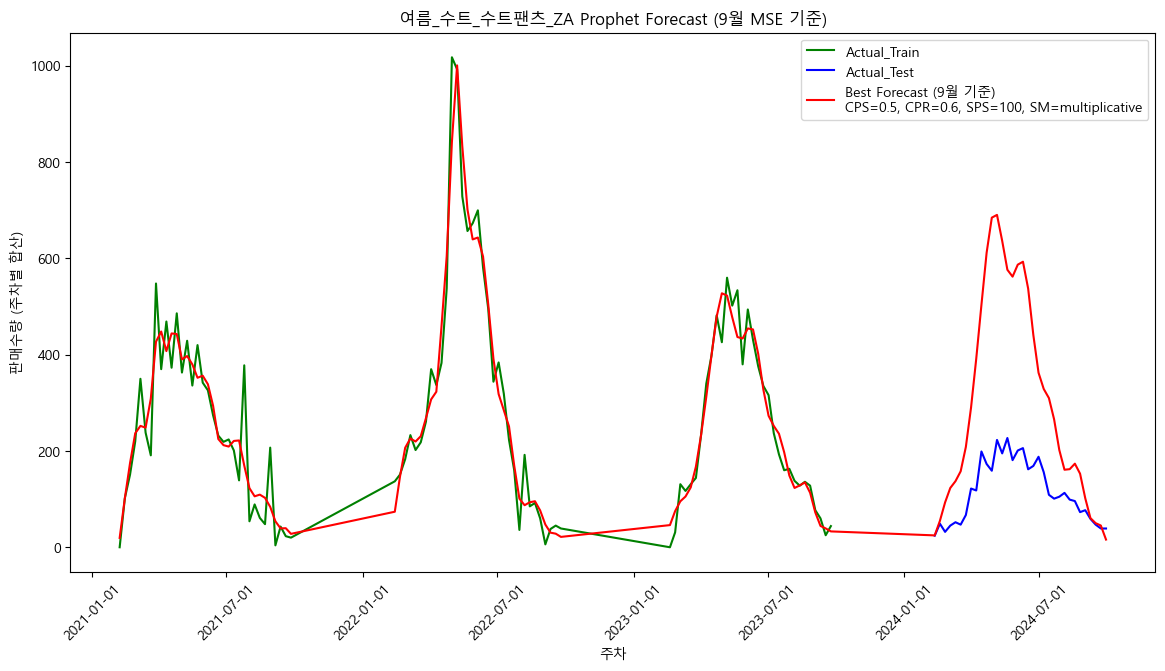


🔹 2024년 9월 실제 판매량: 261 장
🔹 2024년 9월 Prophet 예측 판매량: 0 장


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '여름_수트_수트팬츠_ZA' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '여름_수트_수트팬츠_ZA'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

# 2024년 9월만 따로 추출 (← 핵심 변경)
test_data_nov = test_data[
    (test_data['ds'] >= pd.to_datetime('2024-09-01')) & 
    (test_data['ds'] <= pd.to_datetime('2024-09-30'))
].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, 9월 Test shape: {test_data_nov.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5, 0.6,0.7,0.8,1]
changepoint_range_list = [0.4, 0.5, 0.6,0.7,0.8,1]
seasonality_prior_scale_list = [30, 40, 50,100,200]
seasonality_modes = ['multiplicative']
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])
                future = df[['ds']].copy()
                forecast = m.predict(future)

                # 핵심: 9월만 평가
                mse, rmse = get_metrics(test_data_nov, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n🔍 2024년 9월 예측 MSE 기준 최적 조합:")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast (9월 기준)\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'여름_수트_수트팬츠_ZA Prophet Forecast (9월 MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 9월 실제 vs 예측 총합 비교
actual_sales_nov = test_data_nov['y'].sum()
forecast_sales_nov = best_forecast[
    (best_forecast['ds'] >= '2024-11-01') & 
    (best_forecast['ds'] <= '2024-11-30')
]['yhat'].sum()

print(f"\n🔹 2024년 9월 실제 판매량: {actual_sales_nov:.0f} 장")
print(f"🔹 2024년 9월 Prophet 예측 판매량: {forecast_sales_nov:.0f} 장")


In [27]:
df.columns

Index(['ds', 'y'], dtype='object')

In [23]:
pd.set_option('display.float_format', '{:,.0f}'.format)



2024년 '겨울_사파리_패딩사파리_ZB' 총 판매량: 16650 장
2024년 '겨울_사파리_패딩사파리_ZB' 총 입고수량: 26390 장
최종 학습 데이터 Shape (겨울_사파리_패딩사파리_ZB): (67, 2)

🔹 2025년 '겨울_사파리_패딩사파리_ZB' 총 예상 판매량 : 15206 장
🔹 2025년 '겨울_사파리_패딩사파리_ZB' 입고 계획량 (예비 20% 포함): 18247 장


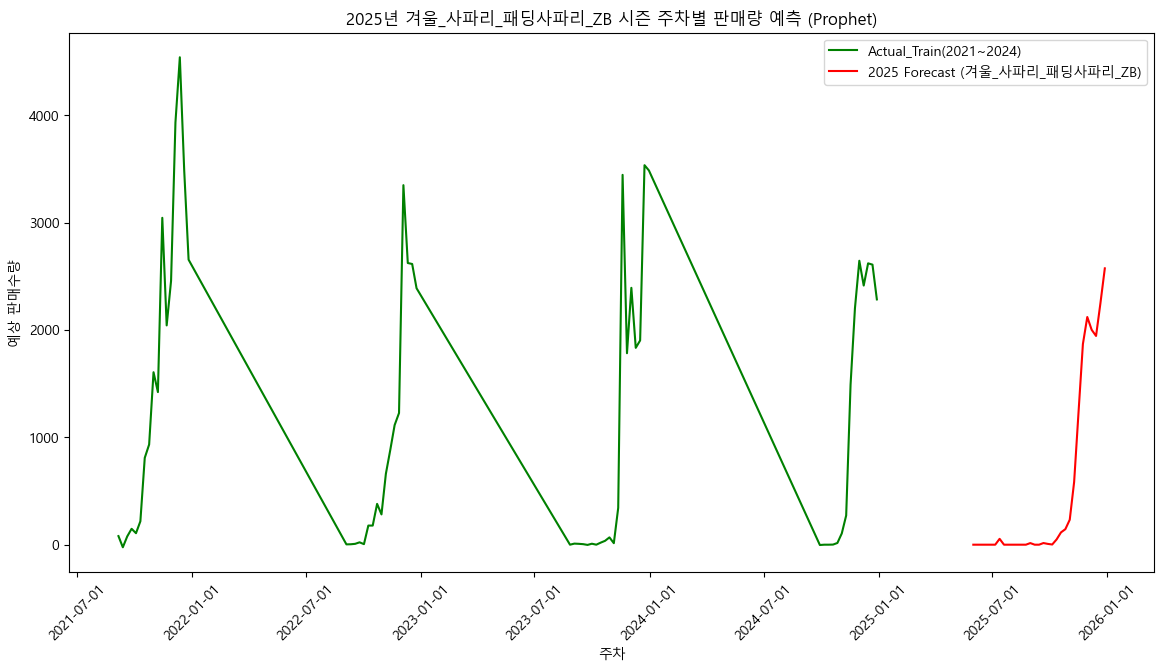

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '겨울패딩사파리'
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_사파리_패딩사파리_ZB'].copy()

# 2024년 '겨울_사파리_패딩사파리_ZB' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '겨울_사파리_패딩사파리_ZB' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '겨울_사파리_패딩사파리_ZB' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (겨울_사파리_패딩사파리_ZB): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.7,
    changepoint_range=0.6,
    seasonality_prior_scale=40, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-06-01', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '겨울_사파리_패딩사파리_ZB' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '겨울_사파리_패딩사파리_ZB' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '겨울_사파리_패딩사파리_ZB' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (겨울_사파리_패딩사파리_ZB)', color='red')
plt.title('2025년 겨울_사파리_패딩사파리_ZB 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


In [17]:
df[['카테고리','주차','주차별_평균_실판매가','평균원가']]

,카테고리,주차,주차별_평균_실판매가,평균원가
1283,겨울_사파리_패딩사파리_ZB,2021-09-05,314364.0,30461
1338,겨울_사파리_패딩사파리_ZB,2021-09-12,492244.0,30461
1391,겨울_사파리_패딩사파리_ZB,2021-09-19,140416.0,30461
1448,겨울_사파리_패딩사파리_ZB,2021-09-26,213328.0,33230
1499,겨울_사파리_패딩사파리_ZB,2021-10-03,677299.0,32986
...,...,...,...,...
8700,겨울_사파리_패딩사파리_ZB,2024-12-01,183111.0,56388
8738,겨울_사파리_패딩사파리_ZB,2024-12-08,155934.0,56388
8776,겨울_사파리_패딩사파리_ZB,2024-12-15,148633.0,56388
8816,겨울_사파리_패딩사파리_ZB,2024-12-22,148634.0,56388


# 사계절_우븐 셔츠_드레스셔츠_ZB

Train shape: (157, 2), Test shape: (52, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.6, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.9, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.9, SPS=100...
🔹 Testing Seasonality=m

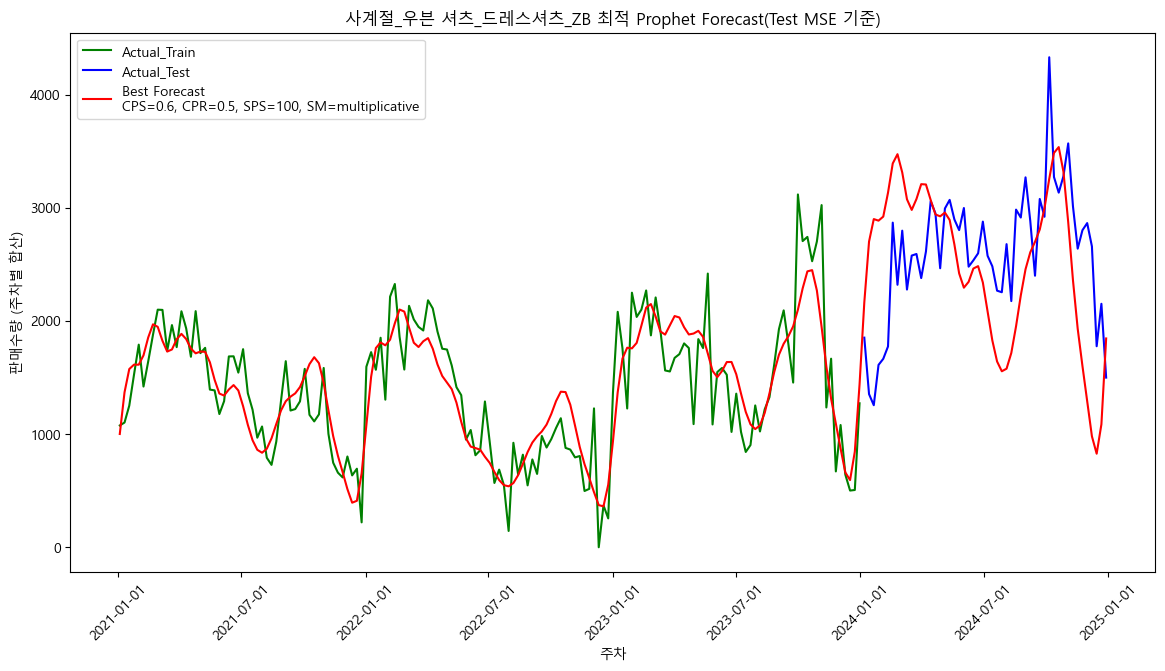


🔹 2024년 실제 총 판매량 ('사계절_우븐 셔츠_드레스셔츠_ZB'): 135501 장
🔹 2024년 Prophet 예측 총 판매량 ('사계절_우븐 셔츠_드레스셔츠_ZB'): 130750 장


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '사계절_우븐 셔츠_드레스셔츠_ZB' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '사계절_우븐 셔츠_드레스셔츠_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5,0.6,0.7] #기본값 0.05
changepoint_range_list = [0.5, 0.6, 0.8, 0.9, 1] #기본값 0.8
seasonality_prior_scale_list = [50, 100, 150, 200] #기본값 10
seasonality_modes = ['multiplicative']  #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'사계절_우븐 셔츠_드레스셔츠_ZB 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 ('사계절_우븐 셔츠_드레스셔츠_ZB'): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 ('사계절_우븐 셔츠_드레스셔츠_ZB'): {forecast_sales_2024:.0f} 장")

In [38]:
# 1. Prophet 예측 결과에서 2024년 주차별 예측값만 추출
forecast_2024 = best_forecast[best_forecast['ds'].dt.year == 2024][['ds', 'yhat']].rename(
    columns={'ds': '주차', 'yhat': 'T_주차예측판매량'})

# 2. 원본 df 불러오기 + 카테고리 필터링 + 2024년만 선택
df_raw = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df_raw['주차'] = pd.to_datetime(df_raw['주차'])
df_2024 = df_raw[(df_raw['카테고리'] == '사계절_우븐 셔츠_드레스셔츠_ZB') & 
                 (df_raw['주차'].dt.year == 2024)].copy()

# ✅ 3. 주차 기준으로 예측값 바로 merge
df_2024 = pd.merge(df_2024, forecast_2024, on='주차', how='left')

# ✅ 4. 매출 및 순이익 계산
df_2024['T_예측매출'] = df_2024['T_주차예측판매량'] * df_2024['주차별_평균_실판매가']
df_2024['T_예측순이익'] = (df_2024['주차별_평균_실판매가'] - df_2024['평균원가']) * df_2024['T_주차예측판매량']

# ✅ 5. 누적합 계산
df_2024['T_누적예측판매량'] = df_2024['T_주차예측판매량'].cumsum()
df_2024['T_누적예측매출'] = df_2024['T_예측매출'].cumsum()
df_2024['T_누적예측순이익'] = df_2024['T_예측순이익'].cumsum()

# 🔍 확인용 출력 (옵션)
df_2024[['카테고리','주차','주차별_평균_실판매가','총입고수량','판매수량','누적판매수량','평균원가','T_주차예측판매량', 'T_누적예측판매량', 'T_누적예측매출', 'T_누적예측순이익']]


,카테고리,주차,주차별_평균_실판매가,총입고수량,판매수량,누적판매수량,평균원가,T_주차예측판매량,T_누적예측판매량,T_누적예측매출,T_누적예측순이익
0,사계절_우븐 셔츠_드레스셔츠_ZB,2024-01-07,"26,717",48189,1852,1852,7917,"2,162","2,162","57,766,753","40,648,836"
1,사계절_우븐 셔츠_드레스셔츠_ZB,2024-01-14,"53,505",48189,1353,3205,7917,"2,701","4,863","202,260,235","163,761,982"
2,사계절_우븐 셔츠_드레스셔츠_ZB,2024-01-21,"23,704",48189,1255,4460,7917,"2,899","7,762","270,986,697","209,534,200"
3,사계절_우븐 셔츠_드레스셔츠_ZB,2024-01-28,"35,962",48189,1611,6071,7917,"2,886","10,648","374,756,282","290,459,010"
4,사계절_우븐 셔츠_드레스셔츠_ZB,2024-02-04,"35,987",48189,1665,7736,7932,"2,921","13,569","479,888,813","372,418,972"
5,사계절_우븐 셔츠_드레스셔츠_ZB,2024-02-11,"36,629",132204,1774,9510,7812,"3,132","16,702","594,628,426","462,687,650"
6,사계절_우븐 셔츠_드레스셔츠_ZB,2024-02-18,"36,536",132204,2868,12378,7812,"3,391","20,092","718,520,761","560,089,759"
7,사계절_우븐 셔츠_드레스셔츠_ZB,2024-02-25,"36,184",132204,2319,14697,7812,"3,473","23,565","844,176,848","658,617,133"
8,사계절_우븐 셔츠_드레스셔츠_ZB,2024-03-03,"36,471",132204,2797,17494,7812,"3,312","26,877","964,952,036","753,522,568"
9,사계절_우븐 셔츠_드레스셔츠_ZB,2024-03-10,"36,408",156781,2277,19771,7559,"3,074","29,951","1,076,871,237","842,205,193"



2024년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 판매량: 135501 장
2024년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 입고수량: 194536 장
최종 학습 데이터 Shape (사계절_우븐 셔츠_드레스셔츠_ZB): (209, 2)

🔹 2025년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 예상 판매량 : 186523 장
🔹 2025년 '사계절_우븐 셔츠_드레스셔츠_ZB' 입고 계획량 (예비 20% 포함): 223828 장


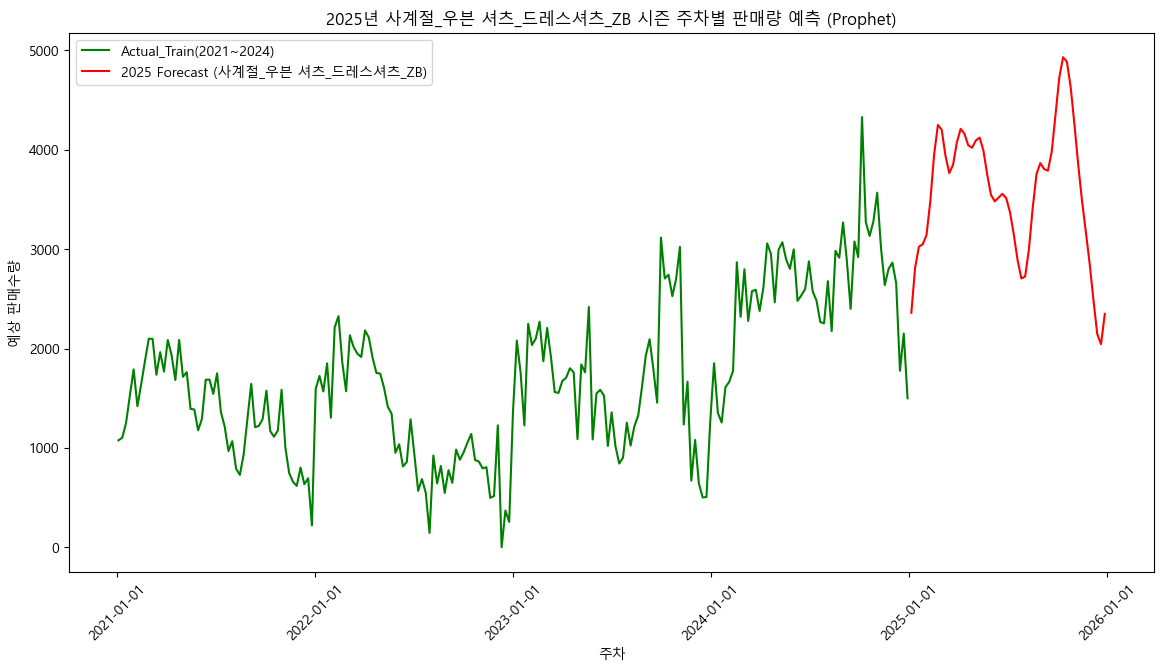

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '사계절_우븐 셔츠_드레스셔츠_ZB'].copy()

# 2024년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (사계절_우븐 셔츠_드레스셔츠_ZB): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.6,
    changepoint_range=0.5,
    seasonality_prior_scale=100, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '사계절_우븐 셔츠_드레스셔츠_ZB' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '사계절_우븐 셔츠_드레스셔츠_ZB' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (사계절_우븐 셔츠_드레스셔츠_ZB)', color='red')
plt.title('2025년 사계절_우븐 셔츠_드레스셔츠_ZB 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()



✅ Bass Model Parameters → p: 0.0072, q: 0.0126, m: 482530

📌 도입기 끝/성장기 시작 (T1): 2025-01-05 (판매량 3460 장)
📌 성장기 끝/성숙기 시작 (T*): 2025-07-20 (판매량 3735 장)
📌 성숙기 끝/쇠퇴기 시작 (T2): 2025-09-14 (판매량 3712 장)

✅ PLC 구간별 누적 판매량 (장):
도입기: 0 장
성장기: 101806 장
성숙기: 29829 장
쇠퇴기: 58291 장


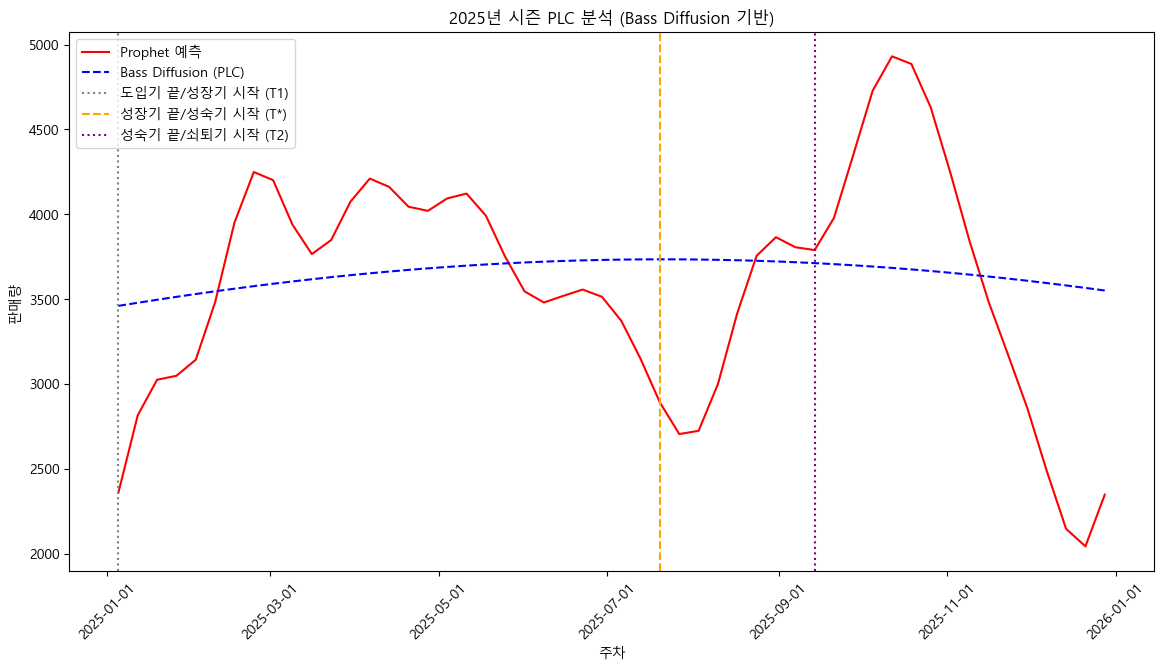

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

# ✅ Prophet 예측 데이터에서 smoothing 추가
forecast_2025['smoothed'] = forecast_2025['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast_2025['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

# ✅ Bass 누적 모델 정의 (cumulative로 curve_fit)
def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

cumulative_sales = np.cumsum(sales_array)

# ✅ 초기값 p0 추가로 안정화
params, _ = curve_fit(bass_cumulative, time, cumulative_sales,
                      p0=[0.01, 0.1, cumulative_sales.max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params

print(f"\n✅ Bass Model Parameters → p: {p:.4f}, q: {q:.4f}, m: {m_val:.0f}")

# ✅ Bass 곡선 생성 (순판매량으로 변환)
cumulative_bass = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(cumulative_bass, 0, 0))

# ✅ PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
T_star_week = forecast_2025['ds'].iloc[T_star_idx]
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T1_week = forecast_2025['ds'].iloc[T1_idx]

total_bass_sales = np.sum(bass_curve)
target_cumulative = total_bass_sales * 0.7
cumulative_bass_sum = np.cumsum(bass_curve)
T2_idx = np.where(cumulative_bass_sum >= target_cumulative)[0][0]
T2_week = forecast_2025['ds'].iloc[T2_idx]

print(f"\n📌 도입기 끝/성장기 시작 (T1): {T1_week.date()} (판매량 {bass_curve[T1_idx]:.0f} 장)")
print(f"📌 성장기 끝/성숙기 시작 (T*): {T_star_week.date()} (판매량 {bass_curve[T_star_idx]:.0f} 장)")
print(f"📌 성숙기 끝/쇠퇴기 시작 (T2): {T2_week.date()} (판매량 {bass_curve[T2_idx]:.0f} 장)")

# ✅ PLC 구간별 누적 판매량 계산
intro_sales = np.sum(bass_curve[:T1_idx])
growth_sales = np.sum(bass_curve[T1_idx:T_star_idx])
mature_sales = np.sum(bass_curve[T_star_idx:T2_idx])
decline_sales = np.sum(bass_curve[T2_idx:])

print("\n✅ PLC 구간별 누적 판매량 (장):")
print(f"도입기: {intro_sales:.0f} 장")
print(f"성장기: {growth_sales:.0f} 장")
print(f"성숙기: {mature_sales:.0f} 장")
print(f"쇠퇴기: {decline_sales:.0f} 장")

# ✅ 시각화
plt.figure(figsize=(14, 7))
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='Prophet 예측', color='red')
plt.plot(forecast_2025['ds'], bass_curve, label='Bass Diffusion (PLC)', color='blue', linestyle='--')
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


In [3]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '사계절_우븐 셔츠_드레스셔츠_ZB'].copy()

# 2. Prophet 학습용 데이터 준비
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 주차 예측
m = Prophet(
    changepoint_prior_scale=0.6,
    changepoint_range=0.5,
    seasonality_prior_scale=100,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산 (T1, T*, T2)
T_star_idx = np.argmax(bass_curve)
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T2_idx = np.where(np.cumsum(bass_curve) >= np.sum(bass_curve) * 0.7)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 예측 결과와 PLC 구간 결합
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 카테고리, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['카테고리'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['카테고리'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
final_df = plc_result[['카테고리', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]


14:59:49 - cmdstanpy - INFO - Chain [1] start processing
14:59:49 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
final_df

,카테고리,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-01-05,2359.819223,3460.412796,성장기,2025-01-05,2025-07-20,2025-09-14
1,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-01-12,2815.849207,3478.662626,성장기,2025-01-05,2025-07-20,2025-09-14
2,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-01-19,3025.051527,3496.373825,성장기,2025-01-05,2025-07-20,2025-09-14
3,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-01-26,3048.488034,3513.533956,성장기,2025-01-05,2025-07-20,2025-09-14
4,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-02-02,3142.963799,3530.130874,성장기,2025-01-05,2025-07-20,2025-09-14
5,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-02-09,3481.647835,3546.152746,성장기,2025-01-05,2025-07-20,2025-09-14
6,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-02-16,3950.313923,3561.588068,성장기,2025-01-05,2025-07-20,2025-09-14
7,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-02-23,4249.011493,3576.425680,성장기,2025-01-05,2025-07-20,2025-09-14
8,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-03-02,4201.142679,3590.654784,성장기,2025-01-05,2025-07-20,2025-09-14
9,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-03-09,3938.907395,3604.264959,성장기,2025-01-05,2025-07-20,2025-09-14


C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kjh27\AppData\Local\Temp\ipykernel_15180\4151321033.py:30: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing f

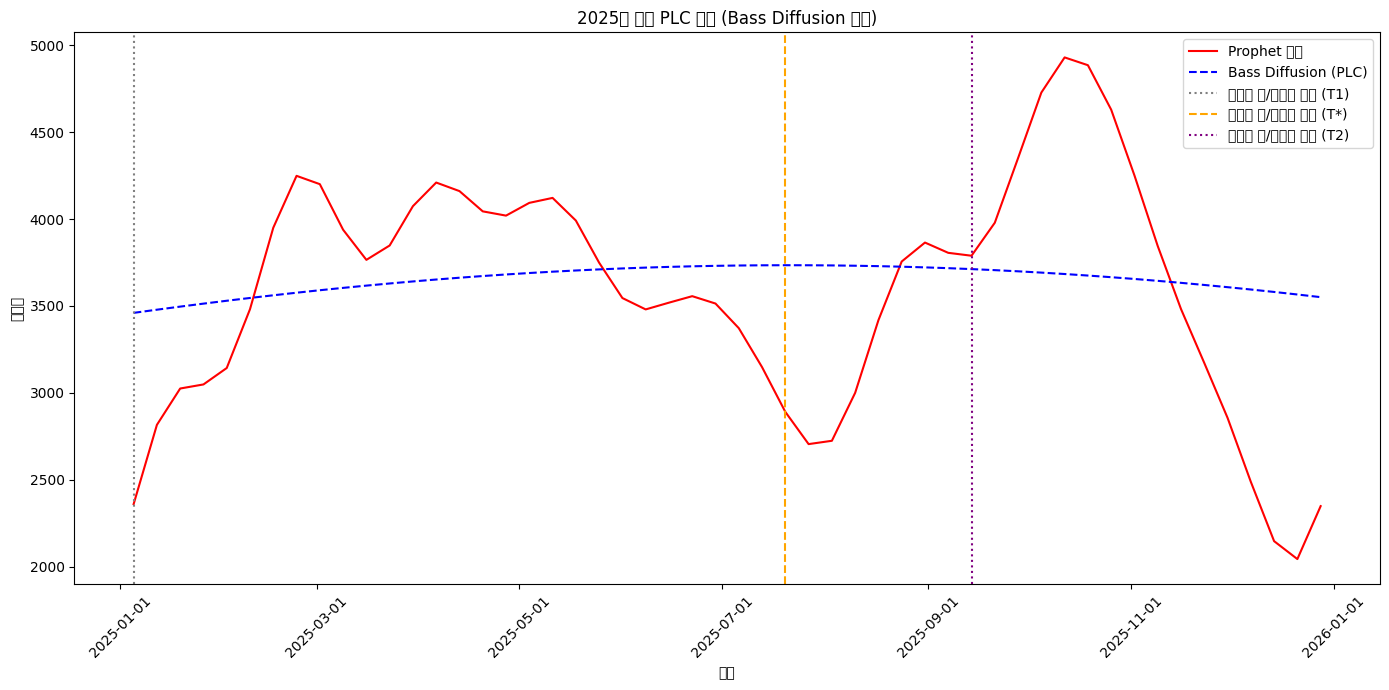

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 전환점 가져오기 (모든 행에 동일하므로 첫 행에서 추출)
T1_week = pd.to_datetime(final_df['T1_week'].iloc[0])
T_star_week = pd.to_datetime(final_df['T_star_week'].iloc[0])
T2_week = pd.to_datetime(final_df['T2_week'].iloc[0])

# 2. 시각화
plt.figure(figsize=(14, 7))

# Prophet 예측선
plt.plot(final_df['주차'], final_df['forecasted_sales'], label='Prophet 예측', color='red')

# Bass 곡선
plt.plot(final_df['주차'], final_df['bass_curve'], label='Bass Diffusion (PLC)', color='blue', linestyle='--')

# PLC 전환점 표시선
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')

# 기타 설정
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.xticks(rotation=45)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


# 겨울_팬츠_팬츠(일반)_ZB

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '겨울_팬츠_팬츠(일반)_ZB' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_팬츠_팬츠(일반)_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# 2022년부터의 데이터로 제한
df = df[df['주차'].dt.year >= 2022].copy()

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5, 0.6, 0.7,0.8] #기본값 0.05
changepoint_range_list = [ 0.3, 0.5, 0.8, 1] #기본값 0.8
seasonality_prior_scale_list = [50, 100, 150, 200] #기본값 10
seasonality_modes = ['multiplicative']  #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'겨울_팬츠_팬츠(일반)_ZB 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 ('겨울_팬츠_팬츠(일반)_ZB'): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 ('겨울_팬츠_팬츠(일반)_ZB'): {forecast_sales_2024:.0f} 장")

Train shape: (34, 2), Test shape: (21, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=1, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=1, SPS=100...
🔹 Testing Seasonality=multip

KeyboardInterrupt: 


2024년 '겨울_팬츠_팬츠(일반)_ZB' 총 판매량: 30329 장
2024년 '겨울_팬츠_팬츠(일반)_ZB' 총 입고수량: 58177 장
최종 학습 데이터 Shape (겨울_팬츠_팬츠(일반)_ZB): (64, 2)

🔹 2025년 '겨울_팬츠_팬츠(일반)_ZB' 총 예상 판매량 : 39347 장
🔹 2025년 '겨울_팬츠_팬츠(일반)_ZB' 입고 계획량 (예비 20% 포함): 47217 장


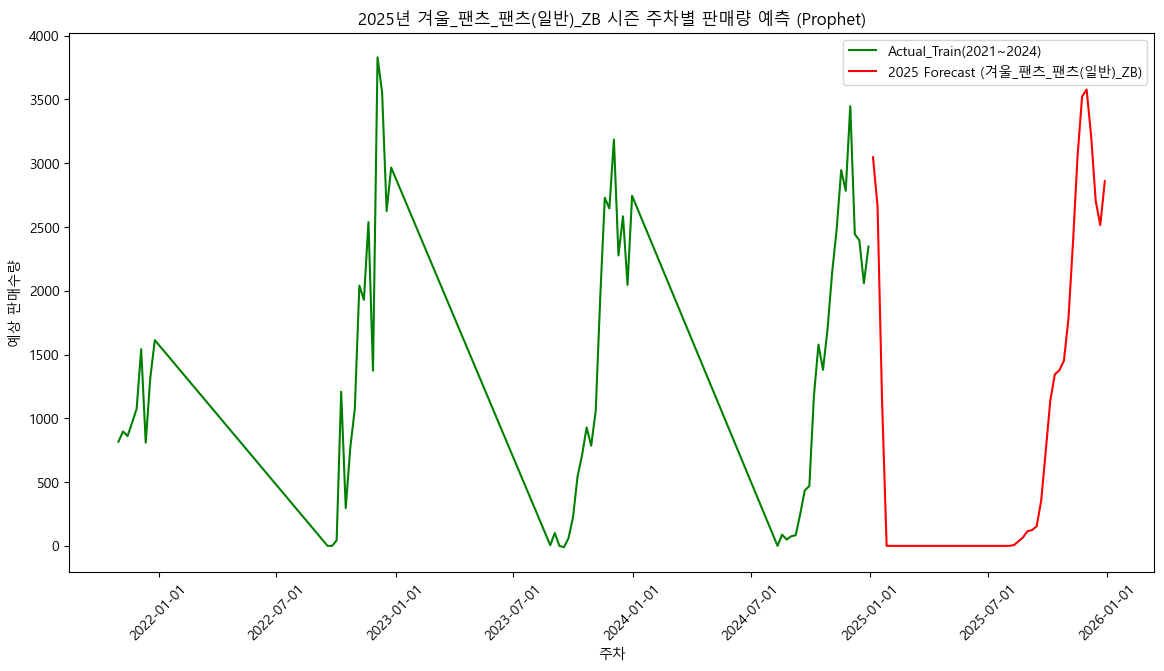

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_팬츠_팬츠(일반)_ZB'].copy()

# 2024년 '겨울_팬츠_팬츠(일반)_ZB' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '겨울_팬츠_팬츠(일반)_ZB' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '겨울_팬츠_팬츠(일반)_ZB' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (겨울_팬츠_팬츠(일반)_ZB): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.5,
    changepoint_range=0.5,
    seasonality_prior_scale=100, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '겨울_팬츠_팬츠(일반)_ZB' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '겨울_팬츠_팬츠(일반)_ZB' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '겨울_팬츠_팬츠(일반)_ZB' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (겨울_팬츠_팬츠(일반)_ZB)', color='red')
plt.title('2025년 겨울_팬츠_팬츠(일반)_ZB 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 가을_우븐 셔츠_캐쥬얼셔츠_ZB

Train shape: (63, 2), Test shape: (21, 2)
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.3, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.5, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=100...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=150...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=0.8, SPS=200...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=1, SPS=50...
🔹 Testing Seasonality=multiplicative, CPS=0.5, CPR=1, SPS=100...
🔹 Testing Seasonality=multip

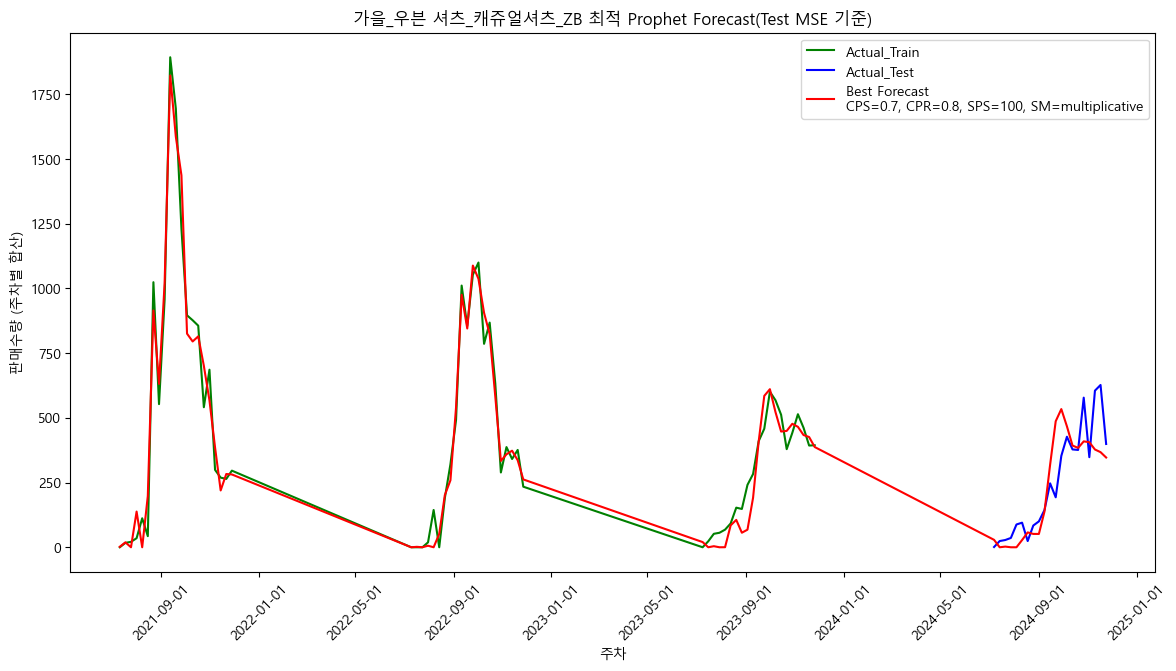


🔹 2024년 실제 총 판매량 ('가을_우븐 셔츠_캐쥬얼셔츠_ZB'): 5155 장
🔹 2024년 Prophet 예측 총 판매량 ('가을_우븐 셔츠_캐쥬얼셔츠_ZB'): 4848 장


In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 및 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '가을_우븐 셔츠_캐쥬얼셔츠_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)

# # 2022년부터의 데이터로 제한
# df = df[df['주차'].dt.year >= 2022].copy()

# 주차별로 판매수량 합산
df = df.groupby('주차', as_index=False)['y'].sum()
df = df.rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 평가 함수
def get_metrics(test_df, forecast_df):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.5, 0.6, 0.7,0.8] #기본값 0.05
changepoint_range_list = [ 0.3, 0.5, 0.8, 1] #기본값 0.8
seasonality_prior_scale_list = [50, 100, 150, 200] #기본값 10
seasonality_modes = ['multiplicative']  #기본값 additive
results = []

# Grid Search 시작
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.fit(train_data[['ds', 'y']])

                future = df[['ds']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics(test_data, forecast)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

# 최적 파라미터 저장
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']

print(f"\nBest Hyperparameters → CPS: {best_cps}, CPR: {best_cpr}, SPS: {best_sps}, Seasonality Mode: {best_sm}")

# 최적 forecast로 시각화
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'가을_우븐 셔츠_캐쥬얼셔츠_ZB 최적 Prophet Forecast(Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량 (주차별 합산)')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

# 2024년 실제 총 판매량과 예측 총 판매량 비교
actual_sales_2024 = test_data['y'].sum()
forecast_sales_2024 = best_forecast[best_forecast['ds'].between('2024-01-01', '2024-12-31')]['yhat'].sum()

print(f"\n🔹 2024년 실제 총 판매량 ('가을_우븐 셔츠_캐쥬얼셔츠_ZB'): {actual_sales_2024:.0f} 장")
print(f"🔹 2024년 Prophet 예측 총 판매량 ('가을_우븐 셔츠_캐쥬얼셔츠_ZB'): {forecast_sales_2024:.0f} 장")


2024년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 판매량: 5155 장
2024년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 입고수량: 9036 장
최종 학습 데이터 Shape (가을_우븐 셔츠_캐쥬얼셔츠_ZB): (84, 2)

🔹 2025년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 예상 판매량 : 6011 장
🔹 2025년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 입고 계획량 (예비 20% 포함): 7213 장


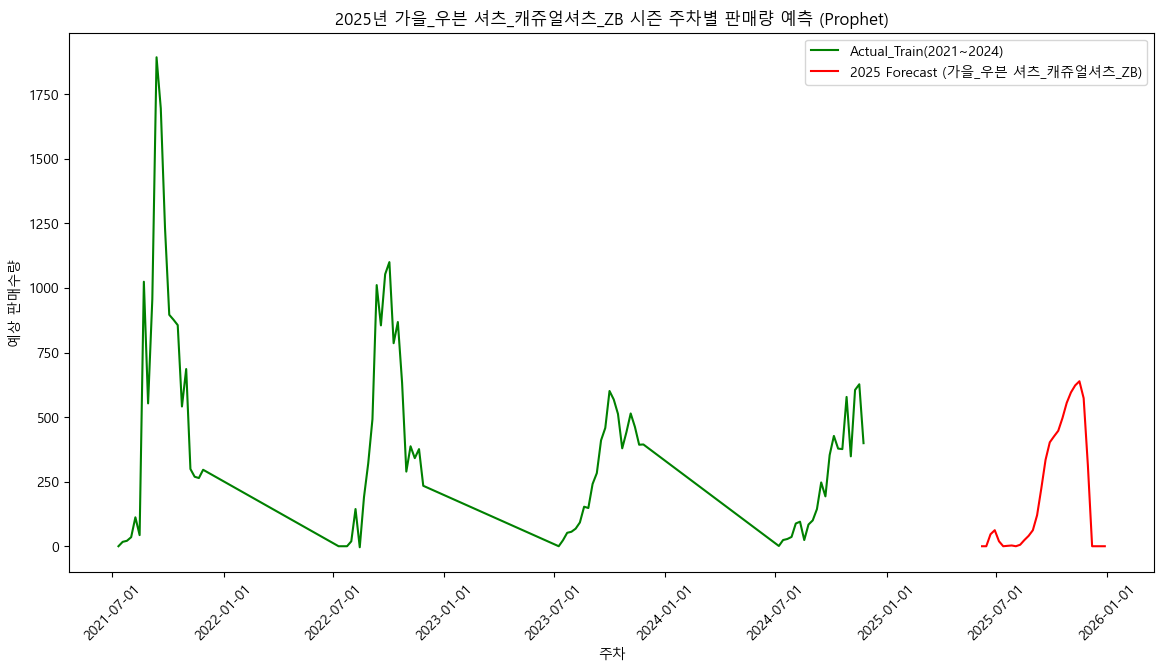

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# 데이터 불러오기 + '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '가을_우븐 셔츠_캐쥬얼셔츠_ZB'].copy()

# 2024년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 판매량 + 총 입고수량 계산
df_2024 = df[df['주차'].dt.year == 2024].copy()
total_sales_2024 = df_2024['판매수량'].sum()
last_inbound = df_2024.groupby('카테고리')['총입고수량'].last().sum()

print(f"\n2024년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 판매량: {total_sales_2024:.0f} 장")
print(f"2024년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 입고수량: {last_inbound:.0f} 장")

# Prophet 학습용, 주차별 판매수량 합산
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})

# 최종 모델 학습용 데이터 (2021~2024)
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)].reset_index(drop=True)
print(f"최종 학습 데이터 Shape (가을_우븐 셔츠_캐쥬얼셔츠_ZB): {final_train.shape}")

# Prophet 모델 생성 (최적 하이퍼파라미터 적용)
m = Prophet(
    changepoint_prior_scale=0.7,
    changepoint_range=0.8,
    seasonality_prior_scale=100, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train[['ds', 'y']])

# 2025년 예측용 future 생성 (일요일 기준)
future_2025 = pd.date_range(start='2025-06-08', end='2025-12-28', freq='W-SUN')
future_2025 = pd.DataFrame({'ds': future_2025})

# 2025년 예측 실행
forecast_2025 = m.predict(future_2025)
forecast_2025['yhat'] = forecast_2025['yhat'].clip(lower=0)

# 2025년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 예상 판매량
total_expected_sales_2025 = forecast_2025['yhat'].sum()
print(f"\n🔹 2025년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 총 예상 판매량 : {total_expected_sales_2025:.0f} 장")

# 예비 20% 더한 입고 계획
inbound_plan_2025 = total_expected_sales_2025 * 1.2
print(f"🔹 2025년 '가을_우븐 셔츠_캐쥬얼셔츠_ZB' 입고 계획량 (예비 20% 포함): {inbound_plan_2025:.0f} 장")

# 판매량 예측 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_train['ds'], final_train['y'], label='Actual_Train(2021~2024)', color='green')
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025 Forecast (가을_우븐 셔츠_캐쥬얼셔츠_ZB)', color='red')
plt.title('2025년 가을_우븐 셔츠_캐쥬얼셔츠_ZB 시즌 주차별 판매량 예측 (Prophet)')
plt.xlabel('주차')
plt.ylabel('예상 판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


# 여름_우븐 셔츠_캐쥬얼셔츠_ZB

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import platform
import warnings
warnings.filterwarnings('ignore')

# 데이터 불러오기 및 전처리
df = pd.read_csv('./data/model_df(음수처리).csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '여름_우븐 셔츠_캐쥬얼셔츠_ZB'].copy()
df['y'] = df['판매수량'].clip(lower=0)
df = df[['주차', 'y', '할인율', '평균기온(도)', '총입고수량']].rename(columns={'주차': 'ds'})

# train/test 분리
train_data = df[(df['ds'].dt.year >= 2021) & (df['ds'].dt.year <= 2023)].reset_index(drop=True)
test_data = df[df['ds'].dt.year == 2024].reset_index(drop=True)

print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# 입고비율 계산 (2024 / 2023)
입고_2023 = df.loc[df['ds'].dt.year == 2023, '총입고수량'].iloc[-1]
입고_2024 = df.loc[df['ds'].dt.year == 2024, '총입고수량'].iloc[-1]
입고비율 = 입고_2024 / 입고_2023
print(f"입고비율 (2024 / 2023): {입고비율:.2f}")

# Test 성능 평가 함수 (입고비율 반영)
def get_metrics_with_scale(test_df, forecast_df, 입고비율):
    forecast_test = pd.merge(test_df[['ds', 'y']], forecast_df[['ds', 'yhat']], on='ds', how='inner')
    forecast_test['yhat_adjusted'] = forecast_test['yhat']
    forecast_test.loc[forecast_test['ds'].dt.year == 2024, 'yhat_adjusted'] *= 입고비율
    mse = mean_squared_error(forecast_test['y'], forecast_test['yhat_adjusted'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 실험 파라미터 세팅
cps_values = [0.05,0.1,0.3] #기본값 0.05
changepoint_range_list = [0.8, 0.9, 1] #기본값 0.8
seasonality_prior_scale_list = [50, 100, 200] #기본값 10
seasonality_modes = ['additive','multiplicative']  #기본값 additive
results = []

# 실험 실행
for seasonality_mode in seasonality_modes:
    for cps in cps_values:
        for cpr in changepoint_range_list:
            for sps in seasonality_prior_scale_list:
                print(f"🔹 Testing Seasonality={seasonality_mode}, CPS={cps}, CPR={cpr}, SPS={sps}...")
                m = Prophet(
                    changepoint_prior_scale=cps,
                    changepoint_range=cpr,
                    seasonality_prior_scale=sps,
                    yearly_seasonality=True,
                    seasonality_mode=seasonality_mode
                )
                m.add_regressor('할인율', prior_scale=10) #기본값 10
                m.add_regressor('평균기온(도)', prior_scale=10) #기본값 10
                m.fit(train_data)

                future = df[['ds', '할인율', '평균기온(도)']].copy()
                forecast = m.predict(future)

                mse, rmse = get_metrics_with_scale(test_data, forecast, 입고비율)
                results.append((cps, cpr, sps, seasonality_mode, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["CPS", "CPR", "SPS", "seasonality_mode", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준 / 입고비율 반영):")
print(results_df.drop(columns=["Forecast"]).head(1))
print("\n전체 성능 비교:")
print(results_df.drop(columns=["Forecast"]))

# 최적 forecast로 입고비율까지 반영 후 시각화
best_cps = results_df.iloc[0]['CPS']
best_cpr = results_df.iloc[0]['CPR']
best_sps = results_df.iloc[0]['SPS']
best_sm = results_df.iloc[0]['seasonality_mode']
best_forecast = results_df.iloc[0]['Forecast']

# yhat 조정 (2024년만 입고비율 반영)
best_forecast['yhat_adjusted'] = best_forecast['yhat']
best_forecast.loc[best_forecast['ds'].dt.year == 2024, 'yhat_adjusted'] *= 입고비율
best_forecast['yhat_adjusted'] = best_forecast['yhat_adjusted'].clip(lower=0)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat_adjusted'],
         label=f'Best Forecast Adjusted\nCPS={best_cps}, CPR={best_cpr}, SPS={best_sps}, SM={best_sm}', color='red')

plt.title(f'최적 Prophet Forecast (입고비율 반영 / Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


In [ ]:
# 2차 실험 파라미터 세팅 (regressor prior_scale 튜닝)
할인_prior_list = [10, 50, 100, 500, 1000]
기온_prior_list = [10, 30, 100, 300, 500]
results = []

for 할인_prior in 할인_prior_list:
    for 기온_prior in 기온_prior_list:
        print(f"🔹 Testing 할인_prior={할인_prior}, 기온_prior={기온_prior} ...")

        m = Prophet(
            changepoint_prior_scale=0.05,
            changepoint_range=0.9,
            seasonality_prior_scale=100,
            yearly_seasonality=True,
            seasonality_mode='multiplicative'
        )
        m.add_regressor('할인율', prior_scale=할인_prior)
        m.add_regressor('평균기온(도)', prior_scale=기온_prior)
        m.fit(train_data)

        future = df[['ds', '할인율', '평균기온(도)']].copy()
        forecast = m.predict(future)

        mse, rmse = get_metrics(test_data, forecast)
        results.append((할인_prior, 기온_prior, mse, rmse, forecast))

# 결과 정리
results_df = pd.DataFrame(results, columns=["할인_prior", "기온_prior", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

print("\n최적 조합 (Test MSE 기준):")
print(results_df.drop(columns=["Forecast"]).head(1))

print("\n전체 성능 비교:")
print(results_df.drop(columns=["Forecast"]))

# 최적 forecast로 시각화
best_할인_prior = results_df.iloc[0]['할인_prior']
best_기온_prior = results_df.iloc[0]['기온_prior']
best_forecast = results_df.iloc[0]['Forecast']
best_forecast['yhat'] = best_forecast['yhat'].clip(lower=0)

plt.figure(figsize=(14, 7))
plt.plot(train_data['ds'], train_data['y'], label='Actual_Train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual_Test', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'],
         label=f'Best Forecast\n할인_prior={best_할인_prior}, 기온_prior={best_기온_prior}', color='red')

plt.title(f'최적 Prophet Forecast (Test MSE 기준)')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()

In [ ]:
## 최종 모델(여름_우븐 셔츠_캐쥬얼셔츠_ZB)

m = Prophet(
            changepoint_prior_scale=0.05,
            changepoint_range=0.9,
            seasonality_prior_scale=100,
            seasonality_mode='multiplicative',
            yearly_seasonality=True
            )
m.add_regressor('할인율', prior_scale=50)
m.add_regressor('평균기온(도)', prior_scale=10)

m.fit(train_data)